# Crypt analysis

In this notebook we automatically segment crypts from villi in the pre-processed organoids. The algorithm is generally quite robust against false positives but does miss crypts where either the crypt- or neck curvature does not deviate significantly from the rest of the organoid. Next, the crypts are analysed, particularly in regards to their marker composition. 

In [33]:
from src.OrganoidMesh import OrganoidMesh
from src.mesh_analysis import *
from src.nonlocal_correlations import *
from src.cell_graph_functions import *
from src.utils import *
from src.crypt_extraction import *
from src.organoid_plotting import *
from src.cell_graph_functions import positive_indices_and_labels

## Load preprocessed data and run crypt segmentation

In [34]:
def _to_patch_list(x):
    """Normalize to list[set[int]]: None -> [], set -> [set], list/tuple -> list of sets."""
    if x is None:
        return []
    if isinstance(x, set):
        return [x]
    if isinstance(x, (list, tuple)):
        return [set(p) for p in x if p is not None and len(p) > 0]
    # anything else: ignore
    return []

In [35]:
import pandas as pd
import numpy as np
import os, glob
from tqdm import tqdm


BLACKLIST = { # Organoids with interior nodes
    "day3p5_B03_10",
    "day4p5_B06_48",
    "day4p5-more_C01_5",
    "day4p5-more_C01_78",
    "day4p5-more_C02_27",
    "day4p5-more_C02_26",
    "day4p5-more_C02_35",
    "day4p5-more_C02_85",
    "day4p5-more_C02_88",
    "day4p5-more_C02_94",
    "day4p5-more_C02_127",
    "day4p5-more_C03_11",
    "day4p5-more_C03_17",
    "day4p5-more_C03_19",
    "day4p5-more_C03_45",
    "day4p5-more_C03_90",
    "day4p5-more_C03_96",
    "day4p5-more_C03_112",
    "day4p5-more_C03_137",
    "day4p5-more_C03_142",
    "day4p5-more_C04_14",
    "day4p5-more_C04_16",
    "day4p5-more_C04_22",
    "day4p5-more_C04_109",
    "day4p5-more_C05_127",
    "day4p5-more_C05_131",
    "day4p5-more_C05_142",
    "day4p5-more_C05_143",
    # the next are from Irene
    'day4p5-more_C01_138',
    'day4p5-more_C01_37', 
    'day4p5-more_C01_5',
    'day4p5-more_C01_53', 
    'day4p5-more_C01_78', 
    'day4p5-more_C01_93',
    'day4p5-more_C01_94', 
    'day4p5-more_C02_103', 
    'day4p5-more_C02_105',
    'day4p5-more_C02_127',
    'day4p5-more_C02_27',
    'day4p5-more_C02_35',
    'day4p5-more_C02_61',
    'day4p5-more_C02_77',
    'day4p5-more_C02_78',
    'day4p5-more_C02_85',
    'day4p5-more_C02_88',
    'day4p5-more_C02_94',
    'day4p5-more_C03_11',
    'day4p5-more_C03_110',
    'day4p5-more_C03_112',
    'day4p5-more_C03_135',
    'day4p5-more_C03_14',
    'day4p5-more_C03_149',
    'day4p5-more_C03_150',
    'day4p5-more_C03_152',
    'day4p5-more_C03_161',
    'day4p5-more_C03_166',
    'day4p5-more_C03_17',
    'day4p5-more_C03_171',
    'day4p5-more_C03_19',
    'day4p5-more_C03_30',
    'day4p5-more_C03_45',
    'day4p5-more_C03_60',
    'day4p5-more_C03_62',
    'day4p5-more_C03_64',
    'day4p5-more_C03_72',
    'day4p5-more_C03_86',
    'day4p5-more_C03_90',
    'day4p5-more_C03_96',
    'day4p5-more_C03_97',
    'day4p5-more_C04_109',
    'day4p5-more_C04_125',
    'day4p5-more_C04_132',
    'day4p5-more_C04_14',
    'day4p5-more_C04_16',
    'day4p5-more_C04_19',
    'day4p5-more_C04_22',
    'day4p5-more_C04_27',
    'day4p5-more_C04_30',
    'day4p5-more_C04_53',    
    'day4p5-more_C04_63', 
    'day4p5-more_C04_70', 
    'day4p5-more_C04_74',
    'day4p5-more_C04_75', 
    'day4p5-more_C04_76', 
    'day4p5-more_C04_80',
    'day4p5-more_C04_96', 
    'day4p5-more_C04_99', 
    'day4p5-more_C05_109',
    'day4p5-more_C05_127', 
    'day4p5-more_C05_131', 
    'day4p5-more_C05_142',
    'day4p5-more_C05_143', 
    'day4p5-more_C05_152', 
    'day4p5-more_C05_21',
    'day4p5-more_C05_4', 
    'day4p5-more_C05_42', 
    'day4p5-more_C05_43',
    'day4p5-more_C05_65', 
    'day4p5-more_C05_67', 
    'day4p5-more_C05_80',
    'day4p5-more_C05_82', 
    'day4p5-more_C05_94', 
    'day4p5-more_C06_100',
    'day4p5-more_C06_139', 
    'day4p5-more_C06_140', 
    'day4p5-more_C06_156',
    'day4p5-more_C06_166', 
    'day4p5-more_C06_175', 
    'day4p5-more_C06_177',
    'day4p5-more_C06_180',
}


marker_names = ['LGR5', 'Chromogranin A', 'Cyclin D', 'Mucin 2', 'AldoB',
                'Glucagon', 'Cyclin A', 'Agr2', 'Serotonin', 'Lysozyme']


# -----------------------------------------
# Load complexity scores from tsne_results.csv
# -----------------------------------------
tsne_df = pd.read_csv("../NicoleData/tsne_results.csv")
complexity_dict = dict(zip(tsne_df["label_uid"], tsne_df["complexity"]))
print(f"Loaded {len(complexity_dict)} complexity scores")

# Base directory for preprocessed data
preproc_base = os.path.join('..', 'NicoleData', 'graphs')

# --- Discover available timepoints dynamically ---
timepoints = sorted(
    [d for d in os.listdir(preproc_base) if os.path.isdir(os.path.join(preproc_base, d))]
)
print(f"Found {len(timepoints)} timepoints: {timepoints}")

timepoints = timepoints[3:] # KEEP ONLY FROM day3p5 ONWARDS
# timepoints = [timepoints[5]] # KEEP ONLY FROM day3p5 ONWARDS


# --- Initialize container ---
results = {}

for tp in timepoints:
    print(f"\n=== Processing timepoint: {tp} ===")

    tp_dir = os.path.join(preproc_base, tp)
    gpickle_files = sorted(glob.glob(os.path.join(tp_dir, "*.gpickle")))
    if not gpickle_files:
        print(f"  ⚠ No .gpickle files found for {tp}, skipping.")
        continue

    # Per-timepoint storage
    complexity_list = []
    label_uid_list = []
    crypt_list = []
    villus_list = []
    neck_list = []
    cell_graphs_list = []

    dropped_no_single_villus = 0  # optional counter
    dropped_blacklisted = 0
    dropped_large_crypt = 0

    for fpath in tqdm(gpickle_files, desc=f"{tp}"):
        try:
            cell_graph = load_cell_graph(fpath)
        except Exception as e:
            print(f"Could not load {fpath}: {e}")
            continue

        try:
          
            label_uid = cell_graph.graph['label_uid']
            complexity_value = complexity_dict.get(label_uid, np.nan)

            # --- Blacklist check (EARLY EXIT) ---
            if label_uid in BLACKLIST:
                dropped_blacklisted += 1
                continue


            crypt_vocab_idx = [1, 2, 7]
            neck_vocab_idx = [0,3,4]

            crypts, necks, villus = segment_organoid_from_vocab(
                cell_graph,
                crypt_vocab_idx=crypt_vocab_idx,
                crypt_thresh=0.2,
                min_crypt_region_size=10,
                neck_vocab_idx=neck_vocab_idx,
                neck_thresh=0.5,
            )

            crypts, necks, villus = grow_crypts_toward_necks(
                cell_graph,
                crypt_regions=crypts,
                neck_regions=necks,   # [] is fine if you didn’t extract necks
                N=2,
                min_villus_region_size=1,
            )


            # --- Keep only organoids with EXACTLY ONE villus ---
            villi_norm = _to_patch_list(villus)
            if len(villi_norm) != 1:        
                dropped_no_single_villus += 1
                # continue  # skip storing this organoid

            total_villus_cells = sum(len(p) for p in villi_norm)

            # --- NEW: drop organoids if ANY crypt is >= total villus size ---
            crypt_patches = _to_patch_list(crypts)         # list[set[int]]
            if crypt_patches and total_villus_cells > 0:
                largest_crypt = max(len(p) for p in crypt_patches)
                if largest_crypt >= total_villus_cells:
                    dropped_large_crypt += 1
                    # continue


            # --- Store ---
            complexity_list.append(complexity_value)
            label_uid_list.append(label_uid)

            crypt_list.append(crypts)
            villus_list.append(villus)
            neck_list.append(necks)

            cell_graphs_list.append(cell_graph)


        except Exception as e:
            print(f"Error analyzing {fpath}: {e}")
            continue

    print(f"  Dropped {dropped_no_single_villus} organoid(s) at {tp} due to villus count != 1")
    print(f"  Skipped {dropped_blacklisted} blacklisted organoid(s) at {tp}")
    print(f"  Dropped {dropped_large_crypt} organoid(s) at {tp} due to crypt >= total villus cells")

    # Stack into object arrays because number of cells differs between organoids
    results[tp] = {
        "complexity": np.array(complexity_list),
        "label_uid": np.array(label_uid_list),
        "crypts_all": crypt_list,
        "villus_all": villus_list,
        "necks_all": neck_list,
        "cell_graphs_all": cell_graphs_list,
    }

    print(f"Stored raw field data for {len(cell_graphs_list)} organoids at {tp}")

Loaded 2668 complexity scores
Found 7 timepoints: ['day2', 'day2p5', 'day3', 'day3p5', 'day4', 'day4p5', 'day4p5-more']

=== Processing timepoint: day3p5 ===


day3p5: 100%|██████████| 312/312 [00:00<00:00, 326.37it/s]


  Dropped 186 organoid(s) at day3p5 due to villus count != 1
  Skipped 1 blacklisted organoid(s) at day3p5
  Dropped 185 organoid(s) at day3p5 due to crypt >= total villus cells
Stored raw field data for 311 organoids at day3p5

=== Processing timepoint: day4 ===


day4: 100%|██████████| 358/358 [00:01<00:00, 257.10it/s]


  Dropped 221 organoid(s) at day4 due to villus count != 1
  Skipped 0 blacklisted organoid(s) at day4
  Dropped 234 organoid(s) at day4 due to crypt >= total villus cells
Stored raw field data for 358 organoids at day4

=== Processing timepoint: day4p5 ===


day4p5: 100%|██████████| 108/108 [00:00<00:00, 133.19it/s]


  Dropped 71 organoid(s) at day4p5 due to villus count != 1
  Skipped 1 blacklisted organoid(s) at day4p5
  Dropped 62 organoid(s) at day4p5 due to crypt >= total villus cells
Stored raw field data for 107 organoids at day4p5

=== Processing timepoint: day4p5-more ===


day4p5-more: 100%|██████████| 533/533 [00:02<00:00, 211.28it/s]

  Dropped 297 organoid(s) at day4p5-more due to villus count != 1
  Skipped 85 blacklisted organoid(s) at day4p5-more
  Dropped 239 organoid(s) at day4p5-more due to crypt >= total villus cells
Stored raw field data for 448 organoids at day4p5-more


## Summary plot to check segmentation

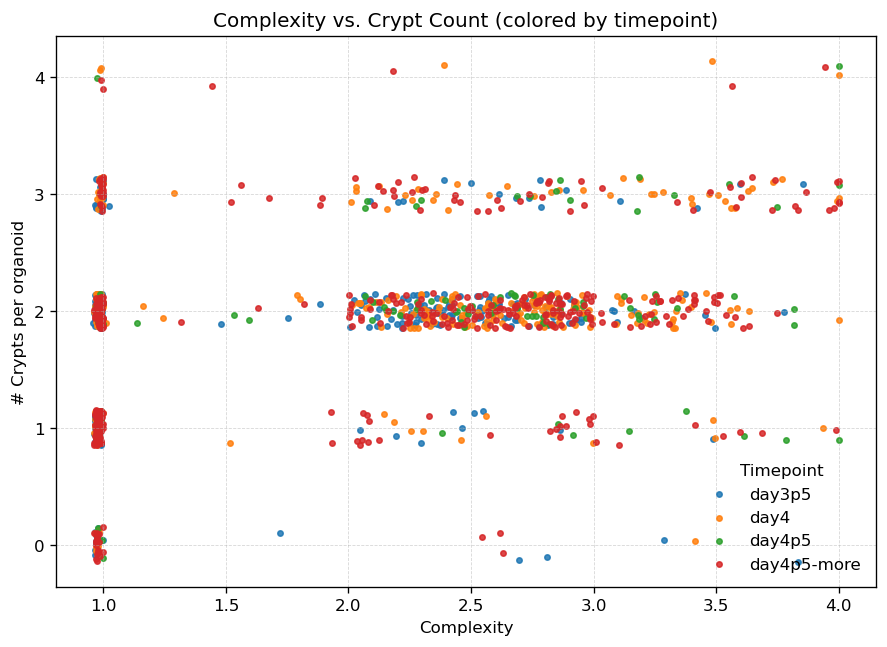

In [36]:
# Collect rows: one per organoid
recs = []
for tp, d in results.items():
    complexities = d.get("complexity", [])
    crypts_all  = d.get("crypts_all", [])
    labels      = d.get("label_uid", [])
    n_items = min(len(complexities), len(crypts_all), len(labels))
    for i in range(n_items):
        cval = complexities[i]
        if cval is None or (isinstance(cval, float) and np.isnan(cval)):
            continue
        crypts_i = crypts_all[i]
        # crypts_i is typically a list (or list-like) of regions; fall back to 0 if None
        n_crypts = len(crypts_i) if crypts_i is not None else 0
        recs.append({
            "timepoint": tp,
            "complexity": float(cval),
            "n_crypts": int(n_crypts),
            "label_uid": labels[i]
        })

df = pd.DataFrame(recs)

# Build a consistent color per timepoint
unique_tps = sorted(df["timepoint"].unique())
cmap = plt.get_cmap("tab10")
color_map = {tp: cmap(i % 10) for i, tp in enumerate(unique_tps)}

plt.figure(figsize=(7.5, 5.5), dpi=120)
for tp in unique_tps:
    sub = df[df["timepoint"] == tp]
    n_crypts_jittered = sub["n_crypts"] + np.random.uniform(-0.15, 0.15, len(sub))

    plt.scatter(
        sub["complexity"],
        n_crypts_jittered,
        label=tp,
        alpha=0.85,
        s=10,
        c=[color_map[tp]]  # keep a single color per timepoint
    )

plt.xlabel("Complexity")
plt.ylabel("# Crypts per organoid")
plt.title("Complexity vs. Crypt Count (colored by timepoint)")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
plt.legend(title="Timepoint", frameon=False)

plt.tight_layout()
plt.show()

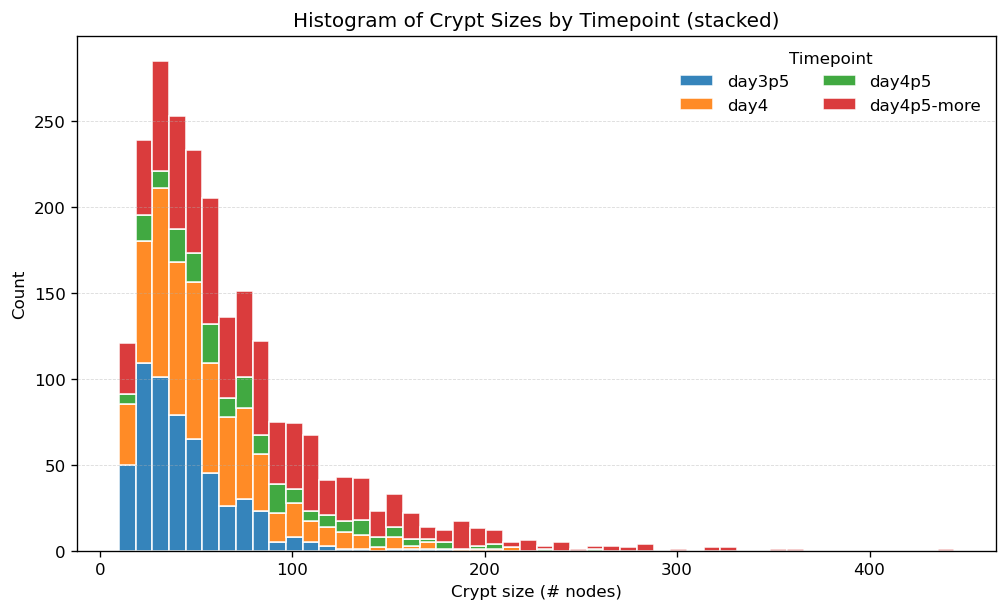

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Build DataFrame of crypt sizes (as you already did)
size_recs = []
for tp, d in results.items():
    crypts_all  = d.get("crypts_all", [])
    labels      = d.get("label_uid", [])
    n_items = min(len(crypts_all), len(labels))
    for i in range(n_items):
        crypts_i = crypts_all[i] or []
        for k, patch in enumerate(crypts_i):
            size_recs.append({
                "timepoint": tp,
                "label_uid": labels[i],
                "crypt_idx": k,
                "size": len(patch),
            })

sizes_df = pd.DataFrame(size_recs)
if sizes_df.empty:
    raise RuntimeError("No crypt sizes to plot.")

# Shared bin edges for all timepoints
bins = 50
bin_edges = np.histogram_bin_edges(sizes_df["size"].values, bins=bins)
bin_widths = np.diff(bin_edges)
bin_centers = bin_edges[:-1] + 0.5 * bin_widths

# Count per timepoint per bin
unique_tps = sorted(sizes_df["timepoint"].unique())
counts_per_tp = []
for tp in unique_tps:
    vals = sizes_df.loc[sizes_df["timepoint"] == tp, "size"].values
    counts, _ = np.histogram(vals, bins=bin_edges)
    counts_per_tp.append(counts)

# Plot stacked bars
plt.figure(figsize=(8.5, 5.2), dpi=120)
bottom = np.zeros_like(bin_centers, dtype=float)

cmap = plt.get_cmap("tab10")
for i, tp in enumerate(unique_tps):
    counts = counts_per_tp[i]
    plt.bar(
        bin_centers,
        counts,
        width=bin_widths,
        bottom=bottom,
        label=str(tp),
        edgecolor="white",
        alpha=0.9,
        align="center",
        color=cmap(i % 10),
    )
    bottom += counts

plt.xlabel("Crypt size (# nodes)")
plt.ylabel("Count")
plt.title("Histogram of Crypt Sizes by Timepoint (stacked)")
plt.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.45)
plt.legend(title="Timepoint", frameon=False, ncol=2)
plt.tight_layout()
plt.show()


In [38]:
import numpy as np

def plot_random_samples_by_filters(
    results,
    k=3,
    n_crypts=None,                 # e.g. 3 for exact match
    n_crypts_range=None,           # e.g. (2, 5) inclusive; ignored if n_crypts is set
    complexity_range=None,         # e.g. (0.2, 0.6) inclusive
    seed=None,
    node_size=2,
    colorscale='YlOrRd'
):
    """
    Pool across all timepoints, filter by #crypts and complexity, sample k organoids, and plot.

    Parameters
    ----------
    results : dict
        Your per-timepoint results structure.
    k : int
        Number of random samples to plot (pooled across timepoints).
    n_crypts : int or None
        Exact number of crypts to match. If provided, overrides n_crypts_range.
    n_crypts_range : (int, int) or None
        Inclusive range for number of crypts; ignored if n_crypts is not None.
    complexity_range : (float, float) or None
        Inclusive range for complexity. If None, no complexity filtering.
    seed : int or None
        Seed for reproducible sampling. If None, sampling is unseeded.
    node_size : int
        Passed to plot_organoid_graph.
    colorscale : str
        Passed to add_region_overlays for crypts overlay.
    """
    # Gather all candidates as (tp, idx) pairs after filtering
    candidates = []
    for tp, d in results.items():
        comp_arr   = d.get("complexity", [])
        crypts_all = d.get("crypts_all", [])
        N = min(len(comp_arr), len(crypts_all))
        for i in range(N):
            cval = comp_arr[i]
            if cval is None or (isinstance(cval, float) and np.isnan(cval)):
                continue

            n_cr = len(crypts_all[i]) if crypts_all[i] is not None else 0

            # Filter by number of crypts
            if n_crypts is not None:
                if n_cr != int(n_crypts):
                    continue
            elif n_crypts_range is not None:
                lo, hi = n_crypts_range
                if not (lo <= n_cr <= hi):
                    continue

            # Filter by complexity
            if complexity_range is not None:
                clo, chi = complexity_range
                if not (clo <= float(cval) <= chi):
                    continue

            candidates.append((tp, i))

    if not candidates:
        msg = "No organoids match the filters"
        parts = []
        if n_crypts is not None: parts.append(f"#crypts == {n_crypts}")
        elif n_crypts_range is not None: parts.append(f"{n_crypts_range[0]} ≤ #crypts ≤ {n_crypts_range[1]}")
        if complexity_range is not None: parts.append(f"{complexity_range[0]} ≤ complexity ≤ {complexity_range[1]}")
        if parts: msg += f" ({', '.join(parts)})."
        print(msg)
        return

    if seed is not None:
        np.random.seed(seed)

    choose_k = min(k, len(candidates))
    sel_idxs = np.random.choice(len(candidates), size=choose_k, replace=False)

    for j in sel_idxs:
        tp, i = candidates[j]
        d = results[tp]

        G = d['cell_graphs_all'][i]
        proj_points = np.array([G.nodes[n]["proj_point"] for n in G.nodes])
        HKS = np.array([G.nodes[n]["hks"] for n in G.nodes])

        fig = plot_organoid_graph(
            proj_points,
            G,
            HKS[:, 0],
            node_size=node_size
        )
        # crypts overlay
        add_region_overlays(fig, proj_points, d['crypts_all'][i], colorscale=colorscale)
        # villus overlay
        # add_region_overlays(fig, d['centroids_all'][i], [d['villus_all'][i]])

        # Optional: annotate for context
        try:
            cval = float(d['complexity'][i])
            n_cr = len(d['crypts_all'][i]) if d['crypts_all'][i] is not None else 0
            fig.update_layout(title=f"{d['label_uid'][i]} | complexity={cval:.3f}, #crypts={n_cr}")
        except Exception:
            pass

        fig.show()



# ---- Example calls ----
# Exact #crypts = 3, any complexity:
plot_random_samples_by_filters(results, k=3, n_crypts=3, complexity_range=(-1, 1))

# #crypts in [2,5] and complexity in [0.2, 0.6]:
# plot_random_samples_by_filters(results, k=4, n_crypts_range=(2,5), complexity_range=(0.2, 0.6))


# Refine and analyze morphology of crypts

In [39]:
data_dir = '../NicoleData/20250929/fractal_output'

timepoints = ['day2', 'day2p5', 'day3', 'day3p5', 'day4', 'day4p5', 'day4p5-more']   # extend as needed: ['day3', 'day3p5', ...]
zarr_names = {tp: 'r0.zarr' for tp in timepoints}
rounds     = {tp: '0_fused_zillum_registered' for tp in timepoints}
meshes     = {tp: 'nnorg_linked_multi_annotated_class' for tp in timepoints}

wells = {
    'day1p5': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day2': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day2p5': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day3': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'B02', 'B03'],
    'day3p5': ['A01', 'A02', 'A03', 'A04', 'B03'],
    'day4': ['A02', 'A03', 'A04', 'A05', 'A06', 'B01', 'B02'],
    'day4p5': ['A06', 'B06'],
    'day4p5-more': ['C01', 'C02', 'C03', 'C04', 'C05', 'C06'],
}

def mesh_path_from_label_uid(label_uid):
    """
    Reconstruct the .vtp mesh path from a label_uid of the form
    '{tp}_{well}_{organoid_id}'.

    This assumes the same directory layout as in preprocess_organoid_graphs.py.
    """
    parts = label_uid.split("_")
    if len(parts) < 3:
        raise ValueError(f"Unexpected label_uid format: {label_uid}")

    tp   = parts[0]
    well = parts[1]
    organoid_id = "_".join(parts[2:])  # in case organoid_id itself has underscores

    plate = well[0]
    field = well[1:]

    zarr_name  = zarr_names[tp]
    round_name = rounds[tp]
    mesh_name  = meshes[tp]

    base_dir = os.path.join(data_dir, tp, zarr_name, plate, field, round_name)
    mesh_dir = os.path.join(base_dir, "meshes", mesh_name)
    mesh_path = os.path.join(mesh_dir, f"{organoid_id}.vtp")

    return mesh_path

In [40]:
from src.crypt_analysis import *

import os
from tqdm import tqdm

# ============================================================
# Helpers to read graph attributes
# ============================================================

def get_proj_vertex_ids_from_graph(G):
    """(N_cells,) int, from node attribute 'proj_vertex'."""
    n = G.number_of_nodes()
    return np.array([int(G.nodes[i]["proj_vertex"]) for i in range(n)], dtype=np.int64)

def get_markers_from_graph(G):
    """(N_cells, M) markers matrix from node attribute 'markers_bin'."""
    return np.asarray([G.nodes[i]["markers_bin"] for i in range(G.number_of_nodes())])


# ============================================================
# Ensemble crypt analysis loop 
# ============================================================

# ---- analysis configuration (match single-organoid notebook) ----
S = 1.5
n_bins = 80
bin_edges   = np.linspace(0.0, S, n_bins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# raw-distance bins for correlations (keep as before; adjust if needed)
bin_edges_raw = np.linspace(0.0, 10.0, n_bins + 1)

# HKS times on mesh vertices
t_hks_vertices = [1.0, 2.0, 4.0, 8.0, 25.0]
t_corr_idx = 0  # which HKS time-scale to correlate (index into t_hks_vertices)

# storage across timepoints
timepoints = list(results.keys())
n_tp = len(timepoints)

M = None
num_pos_per_bin   = None                 # (n_tp, M, n_bins)
num_cells_per_bin = np.zeros((n_tp, n_bins), dtype=float)

# per-timepoint per-crypt lists (convert to arrays at the end)
crypt_circumferences_all  = [[] for _ in range(n_tp)]  # 

curv_mean_all  = [[] for _ in range(n_tp)]  # mean HKS along s (adjusted)
curv_std_all   = [[] for _ in range(n_tp)]  # std  HKS along s (adjusted)

BI_all = [[] for _ in range(n_tp)]
CI_all = [[] for _ in range(n_tp)]
EI_all = [[] for _ in range(n_tp)]


for tp_idx, tp in enumerate(timepoints):  # loop over timepoints
    d = results[tp]

    crypts_all   = d.get("crypts_all", [])
    villus_all   = d.get("villus_all", [])
    necks_all    = d.get("necks_all", [])     # <-- NEW (all extracted necks)
    Gs           = d.get("cell_graphs_all", [])
    label_uids   = d.get("label_uid", [])

    if isinstance(crypts_all, np.ndarray): crypts_all = crypts_all.tolist()
    if isinstance(villus_all, np.ndarray): villus_all = villus_all.tolist()
    if isinstance(necks_all, np.ndarray):  necks_all  = necks_all.tolist()

    for i in tqdm(range(len(Gs)), desc=f"{tp}"):  # loop over organoids in timepoint
        G = Gs[i]

        crypt_patches  = as_patch_list(crypts_all[i] if i < len(crypts_all) else None)
        villus_patches = as_patch_list(villus_all[i] if i < len(villus_all) else None)
        neck_patches   = as_patch_list(necks_all[i]  if i < len(necks_all)  else None)

        if not crypt_patches:
            continue

        # --- per-cell markers ---
        markers_bin = get_markers_from_graph(G)  # (N_cells, M)
        if M is None:
            M = markers_bin.shape[1]
            num_pos_per_bin = np.zeros((n_tp, M, n_bins), dtype=float)

        # --- load mesh for this organoid ---
        label_uid = label_uids[i]
        mesh_path = mesh_path_from_label_uid(label_uid)
        if not os.path.exists(mesh_path):
            print(f"[{tp}] missing mesh: {mesh_path}")
            continue

        mesh = OrganoidMesh(mesh_path)
        mesh._eig_decomp()

        # --- proj vertex ids (cell centers) from graph ---
        proj_vertex_ids = get_proj_vertex_ids_from_graph(G)  # (N_cells,)

        # --- compute vertex-level HKS on this mesh ---
        HKS = compute_hks(mesh, t=t_hks_vertices, coeffs=False)  # (V, T)
        X = HKS[:, t_corr_idx]  # (V,)

        # weights for correlations + field stats
        w_v = vertex_areas(mesh)

        # combine villus + neck into boundary patches (matches single-organoid code)
        boundary_patches = []
        if villus_patches:
            boundary_patches.extend(villus_patches)
        if neck_patches:
            boundary_patches.extend(neck_patches)

        # ============================================================
        # Process each crypt (UPDATED)
        # ============================================================

        K = len(crypt_patches)
        bottom_cell_ids = np.full(K, -1, dtype=int)
        bottom_vertex_ids = np.full(K, -1, dtype=int)
        neck_boundary_cells_list = [None] * K

        # 1) precompute boundary + bottom per crypt
        for j, crypt_cells in enumerate(crypt_patches):
            crypt_cells = set(crypt_cells)
            if len(crypt_cells) == 0:
                continue

            neck_boundary_cells = crypt_neck_boundary_cells(G, crypt_cells, boundary_patches)
            if len(neck_boundary_cells) == 0:
                continue

            bottom_cell_id, _ = find_crypt_bottom_lightweight(
                G=G, mesh=mesh, crypt_cells=crypt_cells,
                neck_boundary_cells=neck_boundary_cells,
                candidates="all", score="cv"
            )

            bottom_cell_ids[j] = int(bottom_cell_id)
            bottom_vertex_ids[j] = int(G.nodes[int(bottom_cell_id)]["proj_vertex"])
            neck_boundary_cells_list[j] = list(neck_boundary_cells)


        valid = bottom_vertex_ids >= 0
        sources = bottom_vertex_ids[valid].tolist()

        # Multi-source geodesics: should return distances from each source to all vertices
        # You need to adapt this line to your compute_geodesics signature/return format
        D_vertices_multi = compute_geodesics(mesh, sources=sources, t=None)  # shape (len(sources), V) ideally


        # index mapping from crypt j -> row in D_vertices_multi
        src_idx_map = {crypt_j: k for k, crypt_j in enumerate(np.where(valid)[0])}

        dnorm_cellcenters_crypts = np.full((len(crypt_patches), G.number_of_nodes()), np.nan, dtype=float)

        for j, crypt_cells in enumerate(crypt_patches):
            if bottom_vertex_ids[j] < 0:
                continue

            k = src_idx_map[j]
            dist_vertices = D_vertices_multi[k, :]  # (V,)

            # compute L_mean using boundary cells -> boundary vertices
            neck_boundary_cells = neck_boundary_cells_list[j]
            boundary_vertex_ids = np.array([int(G.nodes[c]["proj_vertex"]) for c in neck_boundary_cells], dtype=int)

            L_mean = float(np.mean(dist_vertices[boundary_vertex_ids]))

            # normalized distances (vertices)
            dnorm_vertices = dist_vertices / max(L_mean, 1e-12)

            # cellcenter distances: evaluate at proj vertices
            dnorm_cellcenters = dnorm_vertices[proj_vertex_ids]
            dist_cellcenters = dist_vertices[proj_vertex_ids]

            # 3) circumference vs distance 
            CC = crypt_circumference(mesh=mesh, crypt_dist=dnorm_vertices, levels=bin_centers)

            # 3b) adjust crypt length -> s_star, update distance fields, compute L_crypt
            s_star = adjust_cryptlength_by_circumference(
                s=bin_centers,
                C=CC,
                search_interval=(0.75, 1.25),
                window_length=9,
                polyorder=3,
                min_prominence=0.05,
            )
            if not (np.isfinite(s_star) and s_star > 0):
                s_star = 1.0

            L_crypt = float(L_mean) * float(s_star)

            dnorm_vertices_adj = dnorm_vertices / float(s_star)
            dnorm_cellcenters_adj = dnorm_cellcenters / float(s_star)

            # 3c) circumference vs distance (ADJ: recompute on adjusted distance field)
            CC = crypt_circumference(mesh=mesh, crypt_dist=dnorm_vertices_adj, levels=bin_centers)


            crypt_circumferences_all[tp_idx].append(CC)
            dnorm_cellcenters_crypts[j] = dnorm_cellcenters_adj

            # 4) marker positivity vs distance (use adjusted distances!)
            counts_pos, counts_tot = bin_marker_positivity(
                markers=markers_bin,
                distance=dnorm_cellcenters_adj,
                bin_edges=bin_edges,
            )
            num_pos_per_bin[tp_idx] += counts_pos
            num_cells_per_bin[tp_idx] += counts_tot


            # 5) curvature stats along s (use adjusted distances!)
            mu_s, sd_s, _ = field_stats_along_crypt(
                HKS[:, 0],
                dnorm_vertices_adj,
                bin_edges,
                weights=w_v,
            )
            curv_mean_all[tp_idx].append(mu_s)
            curv_std_all[tp_idx].append(sd_s)

            # 6) morphometrics (BI, CI, EI)
            BI, CI, EI = compute_crypt_metrics(
                s=bin_centers,
                C=CC,
                L=L_crypt,
                mu_hks=mu_s,
                std_hks=sd_s,
            )
            BI_all[tp_idx].append(BI)
            CI_all[tp_idx].append(CI)
            EI_all[tp_idx].append(EI)

        # Readjust crypt boundary to neckline
        crypt_patches_adj, _, _ = assign_crypts_by_neckline(dnorm_cellcenters_crypts)
        
        # ------------------------------
        # UPDATE results[tp]["crypts_all"][i] IN-PLACE
        # ------------------------------
        # Ensure storage exists and is long enough
        if "crypts_all" not in results[tp]:
            results[tp]["crypts_all"] = []
        while len(results[tp]["crypts_all"]) <= i:
            results[tp]["crypts_all"].append([])

        # Convert to list-of-lists (JSON/pickle friendly), drop empties
        results[tp]["crypts_all"][i] = [
            sorted(list(p)) for p in crypt_patches_adj if (p is not None and len(p) > 0)
        ]



heat sources: 100%|██████████| 1/1 [00:00<00:00, 195.00it/s]]
/home/fmoller/Projects/LearningOrganoids/SphericalHarmonics/src/crypt_analysis.py:1076: RuntimeWarning:

divide by zero encountered in scalar divide

heat sources: 100%|██████████| 1/1 [00:00<00:00, 195.83it/s]t]
heat sources: 0it [00:00, ?it/s]0/448 [17:21<11:13,  3.58s/it]
day4p5-more: 100%|██████████| 448/448 [29:25<00:00,  3.94s/it]


In [41]:

# ============================================================
# Convert per-crypt lists into arrays for convenience
# ============================================================

def _list_to_array(list_of_vecs, n_bins):
    return np.asarray(list_of_vecs) if len(list_of_vecs) else np.empty((0, n_bins), dtype=float)

crypt_circumferences_all     = [_list_to_array(x, n_bins) for x in crypt_circumferences_all]

curv_mean_all = [_list_to_array(x, n_bins) for x in curv_mean_all]
curv_std_all  = [_list_to_array(x, n_bins) for x in curv_std_all]

BI_all = [np.asarray(x, dtype=float) if len(x) else np.empty((0,), dtype=float) for x in BI_all]
CI_all = [np.asarray(x, dtype=float) if len(x) else np.empty((0,), dtype=float) for x in CI_all]
EI_all = [np.asarray(x, dtype=float) if len(x) else np.empty((0,), dtype=float) for x in EI_all]


# Analyse marker content of crypts

In [42]:
def get_marker_counts_per_patch(patch, markers):
    idx = np.fromiter(patch, dtype=np.int64)
    num_pos_cells = np.sum(markers[idx, :], axis=0).astype(np.int64)
    num_cells = len(idx)
    return num_pos_cells, num_cells

def split_villus_by_organoid(villus_patches, crypt_patches):
    """Return (villus_only, villus_with_crypts) as two lists of sets."""
    if crypt_patches and len(crypt_patches) > 0:
        return [], list(villus_patches)
    else:
        return list(villus_patches), []

def marker_coexpression(patch, bin_markers, i_LGR5, i_Sero, i_Lyso, pos_threshold=1):
    idx = np.fromiter(patch, dtype=np.int64)
    bin_markers_patch = bin_markers[idx, :]

    coexpression = np.ndarray(4)
    has_marker = np.sum(bin_markers_patch, axis=0) >= pos_threshold

    coexpression[0] = has_marker[i_LGR5] and has_marker[i_Sero] and not has_marker[i_Lyso] 
    coexpression[1] = has_marker[i_LGR5] and has_marker[i_Lyso] and not has_marker[i_Sero]
    coexpression[2] = has_marker[i_LGR5] and not has_marker[i_Lyso] and not has_marker[i_Sero] 
    coexpression[3] = has_marker[i_LGR5] and (has_marker[i_Lyso] and has_marker[i_Sero])

    return coexpression.astype(np.int64)


# --- configuration ---
min_positive = 1

# --- aggregate across all timepoints/organoids ---

num_crypts = np.zeros(len(timepoints), dtype=np.int64)
num_villus = np.zeros(len(timepoints), dtype=np.int64)
num_single = np.zeros(len(timepoints), dtype=np.int64)
marker_pos_crypt = np.zeros((len(timepoints), len(marker_names)), dtype=np.int64)
marker_pos_villus = np.zeros((len(timepoints), len(marker_names)), dtype=np.int64)
marker_pos_single = np.zeros((len(timepoints), len(marker_names)), dtype=np.int64)

num_pos_cells_crypt = np.zeros((len(timepoints), len(marker_names)), dtype=np.int64)
num_pos_cells_villus = np.zeros((len(timepoints), len(marker_names)), dtype=np.int64)
num_pos_cells_single = np.zeros((len(timepoints), len(marker_names)), dtype=np.int64)
num_cells_crypt = np.zeros(len(timepoints), dtype=np.int64)
num_cells_villus = np.zeros(len(timepoints), dtype=np.int64)
num_cells_single = np.zeros(len(timepoints), dtype=np.int64)


coexpression_crypt = np.zeros((len(timepoints), 4))
coexpression_villus = np.zeros((len(timepoints), 4))
coexpression_single = np.zeros((len(timepoints), 4))


j = -1
for tp, d in results.items(): # loop over timepoints
    graphs_all   = d.get("cell_graphs_all", [])
    crypts_all   = d.get("crypts_all",   [])
    villus_all   = d.get("villus_all",   [])

    i_LGR5 = marker_names.index("LGR5")  # raises ValueError if not found
    i_Sero = marker_names.index("Serotonin")  # raises ValueError if not found
    i_Lyso = marker_names.index("Lysozyme")  # raises ValueError if not found

    j += 1

    if isinstance(crypts_all, np.ndarray): crypts_all = crypts_all.tolist()
    if isinstance(villus_all, np.ndarray): villus_all = villus_all.tolist()

    n_items = len(graphs_all)
    for i in range(n_items): # loop over organoids in timepoint
        markers = np.array([graphs_all[i].nodes[n]["markers_bin"] for n in graphs_all[i].nodes])
        
        if markers is None:
            continue

        crypt_patches = _to_patch_list(crypts_all[i] if i < len(crypts_all) else None)
        villus_patches = _to_patch_list(villus_all[i] if i < len(villus_all) else None)

        # (OPTIONAL) filter out regions with too few cells
        # crypt_patches  = [p for p in crypt_patches  if len(p) >= min_cells]
        # villus_patches = [p for p in villus_patches if len(p) >= min_cells]

        villus_only, villus_with = split_villus_by_organoid(villus_patches, crypt_patches)

        # --- CRYPTS (patch-wise + cell-wise) ---
        for patch in crypt_patches:
            num_pos_cells, num_cells = get_marker_counts_per_patch(patch, markers)
            
            num_cells_crypt[j] += num_cells
            num_pos_cells_crypt[j,:] += num_pos_cells
            marker_pos_crypt[j,:] += (num_pos_cells >= min_positive) 
            num_crypts[j] += 1
            coexpression_crypt[j,:] += marker_coexpression(patch, markers, i_LGR5, i_Sero, i_Lyso)


        # --- VILLUS WITH CRYPTS---
        for patch in villus_with:
            num_pos_cells, num_cells = get_marker_counts_per_patch(patch, markers)
            
            num_cells_villus[j] += num_cells
            num_pos_cells_villus[j,:] += num_pos_cells
            marker_pos_villus[j,:] += (num_pos_cells >= min_positive) 
            num_villus[j] += 1
            coexpression_villus[j,:] += marker_coexpression(patch, markers, i_LGR5, i_Sero, i_Lyso)


        # --- VILLUS WITHOUT CRYPTS---
        for patch in villus_only:
            num_pos_cells, num_cells = get_marker_counts_per_patch(patch, markers)
            
            num_cells_single[j] += num_cells
            num_pos_cells_single[j,:] += num_pos_cells
            marker_pos_single[j,:] += (num_pos_cells >= min_positive) 
            num_single[j] += 1
            coexpression_single[j,:] += marker_coexpression(patch, markers, i_LGR5, i_Sero, i_Lyso)



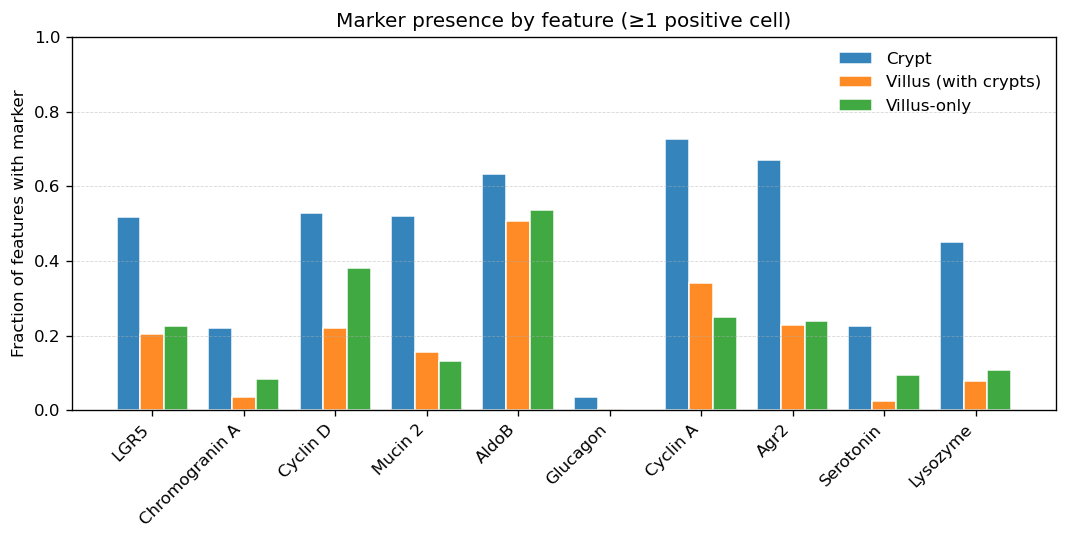

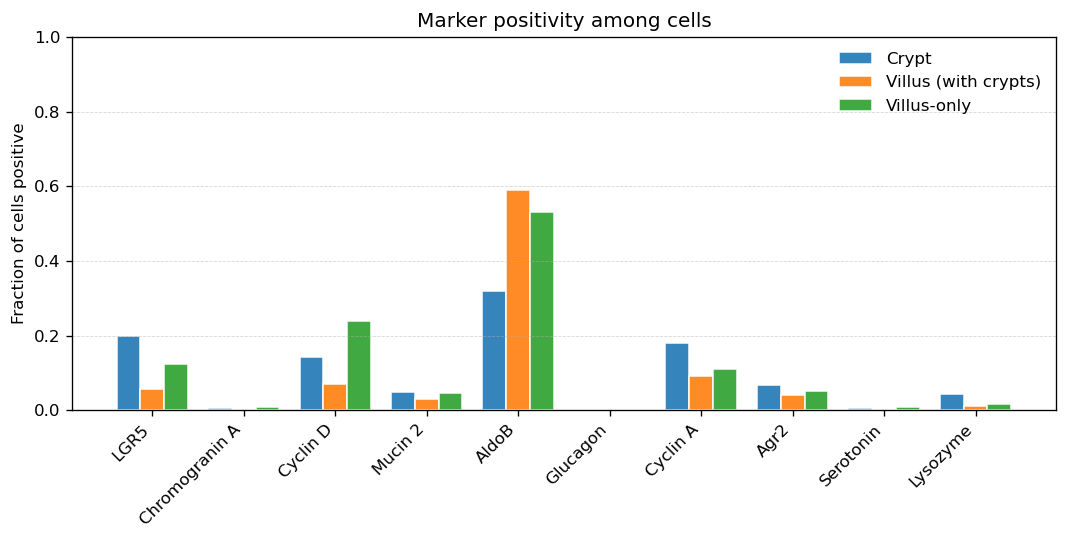

In [43]:
# --- Plotting: grouped bars with three categories ---

def _plot_grouped_bars_3(crypt_vals, villus_with_vals, villus_only_vals, ylabel, title):
    m = len(marker_names)
    x = np.arange(m)
    w = 0.26

    plt.figure(figsize=(max(9, 0.5*m), 4.6), dpi=120)
    plt.bar(x - w,      crypt_vals,        width=w, label="Crypt",               edgecolor="white", alpha=0.9)
    plt.bar(x,          villus_with_vals,  width=w, label="Villus (with crypts)",edgecolor="white", alpha=0.9)
    plt.bar(x + w,      villus_only_vals,  width=w, label="Villus-only",         edgecolor="white", alpha=0.9)
    plt.xticks(x, marker_names, rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

# Figure 1
_plot_grouped_bars_3(
    np.sum(marker_pos_crypt, axis=0)/np.sum(num_crypts),
    np.sum(marker_pos_villus, axis=0)/np.sum(num_villus),
    np.sum(marker_pos_single, axis=0)/np.sum(num_single),
    ylabel="Fraction of features with marker",
    title=f"Marker presence by feature (≥{min_positive} positive cell)"
)

# Figure 2
_plot_grouped_bars_3(
    np.sum(num_pos_cells_crypt, axis=0)/np.sum(num_cells_crypt),
    np.sum(num_pos_cells_villus, axis=0)/np.sum(num_cells_villus),
    np.sum(num_pos_cells_single, axis=0)/np.sum(num_cells_single),
    ylabel="Fraction of cells positive",
    title="Marker positivity among cells"
)


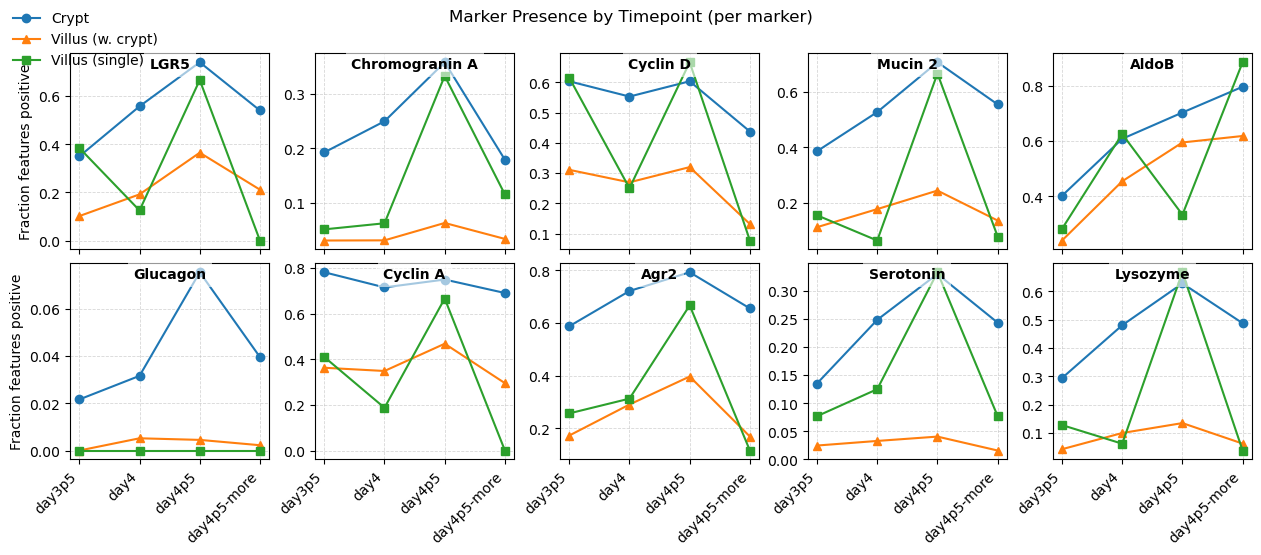

In [44]:
x = np.arange(len(timepoints))
M = len(marker_names)
n_cols = 5
n_rows = int(np.ceil(M / n_cols))

fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(2.5 * n_cols, 2.5 * n_rows),
        sharex=True, sharey=False,
        constrained_layout=True
    )

for i in range(M):
    r, c = divmod(i, n_cols)
    ax = axes[r, c]

    ax.plot(x, marker_pos_crypt[:,i]/num_crypts, marker='o', label='Crypt')
    ax.plot(x, marker_pos_villus[:,i]/num_villus, marker='^', label='Villus (w. crypt)')
    ax.plot(x, marker_pos_single[:,i]/num_single, marker='s', label='Villus (single)')

    ax.text(
        0.5, 0.98,                       # near the top-center of the axes
        marker_names[i],
        transform=ax.transAxes,
        ha="center", va="top",
        fontweight="bold", fontsize=10,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.6)  # optional halo for readability
    )
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)

    # x ticks = timepoints (rotate for readability)
    ax.set_xticks(x)
    ax.set_xticklabels(timepoints, rotation=45, ha="right")

    # y-label only on leftmost column
    if c == 0:
        ax.set_ylabel("Fraction features positive")

    # Single, figure-level legend
    # (grab handles/labels from the first visible axis)
    for rr in range(n_rows):
        for cc in range(n_cols):
            if axes[rr, cc].get_visible():
                handles, labels = axes[rr, cc].get_legend_handles_labels()
                break
        else:
            continue
        break


fig.legend(handles, labels, loc="upper left", ncol=1, frameon=False)
fig.suptitle("Marker Presence by Timepoint (per marker)", y=1.08, fontsize=12)
plt.show()

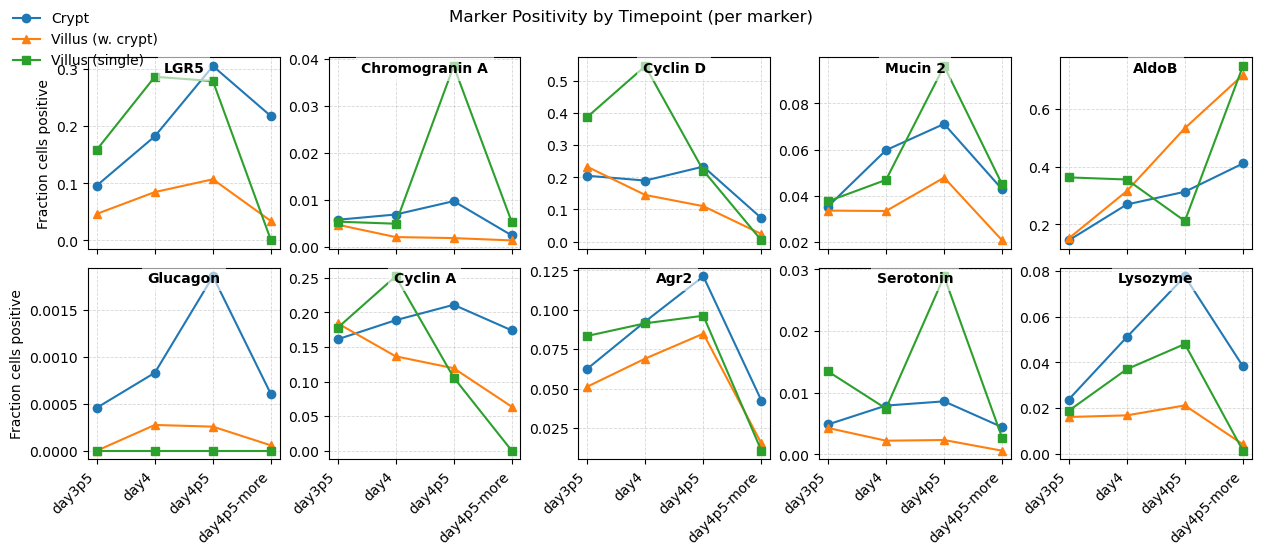

In [45]:
x = np.arange(len(timepoints))
M = len(marker_names)
n_cols = 5
n_rows = int(np.ceil(M / n_cols))

fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(2.5 * n_cols, 2.5 * n_rows),
        sharex=True, sharey=False,
        constrained_layout=True
    )

for i in range(M):
    r, c = divmod(i, n_cols)
    ax = axes[r, c]

    ax.plot(x, num_pos_cells_crypt[:,i]/num_cells_crypt, marker='o', label='Crypt')
    ax.plot(x, num_pos_cells_villus[:,i]/num_cells_villus, marker='^', label='Villus (w. crypt)')
    ax.plot(x, num_pos_cells_single[:,i]/num_cells_single, marker='s', label='Villus (single)')

    ax.text(
        0.5, 0.98,                       # near the top-center of the axes
        marker_names[i],
        transform=ax.transAxes,
        ha="center", va="top",
        fontweight="bold", fontsize=10,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.6)  # optional halo for readability
    )
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)

    # x ticks = timepoints (rotate for readability)
    ax.set_xticks(x)
    ax.set_xticklabels(timepoints, rotation=45, ha="right")

    # y-label only on leftmost column
    if c == 0:
        ax.set_ylabel("Fraction cells positive")

    # Single, figure-level legend
    # (grab handles/labels from the first visible axis)
    for rr in range(n_rows):
        for cc in range(n_cols):
            if axes[rr, cc].get_visible():
                handles, labels = axes[rr, cc].get_legend_handles_labels()
                break
        else:
            continue
        break


fig.legend(handles, labels, loc="upper left", ncol=1, frameon=False)
fig.suptitle("Marker Positivity by Timepoint (per marker)", y=1.08, fontsize=12)
plt.show()

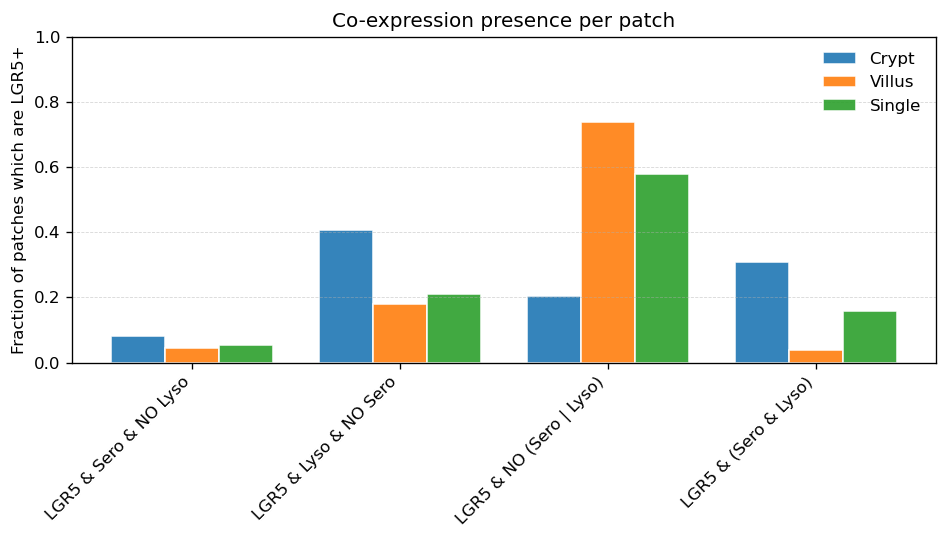

In [46]:
# --- Fractions per condition ---
labels_cond = [
    "LGR5 & Sero & NO Lyso",
    "LGR5 & Lyso & NO Sero",
    "LGR5 & NO (Sero | Lyso)",
    "LGR5 & (Sero & Lyso)",
]


# --- Plot grouped bars (crypt vs villus) ---
x = np.arange(len(labels_cond))
w = 0.26

plt.figure(figsize=(max(8, 0.6*len(labels_cond)), 4.6), dpi=120)
plt.bar(x - w, np.sum(coexpression_crypt, axis=0)/np.sum(marker_pos_crypt[:,i_LGR5], axis=0),  width=w, label="Crypt",  edgecolor="white", alpha=0.9)
plt.bar(x , np.sum(coexpression_villus, axis=0)/np.sum(marker_pos_villus[:,i_LGR5], axis=0), width=w, label="Villus", edgecolor="white", alpha=0.9)
plt.bar(x + w, np.sum(coexpression_single, axis=0)/np.sum(marker_pos_single[:,i_LGR5], axis=0), width=w, label="Single", edgecolor="white", alpha=0.9)
plt.xticks(x, labels_cond, rotation=45, ha="right")
plt.ylim(0, 1)
plt.ylabel("Fraction of patches which are LGR5+")
plt.title("Co-expression presence per patch")
plt.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1491550/3816897602.py:18: RuntimeWarning:

invalid value encountered in divide

/tmp/ipykernel_1491550/3816897602.py:18: RuntimeWarning:

invalid value encountered in divide

/tmp/ipykernel_1491550/3816897602.py:18: RuntimeWarning:

invalid value encountered in divide

/tmp/ipykernel_1491550/3816897602.py:18: RuntimeWarning:

invalid value encountered in divide



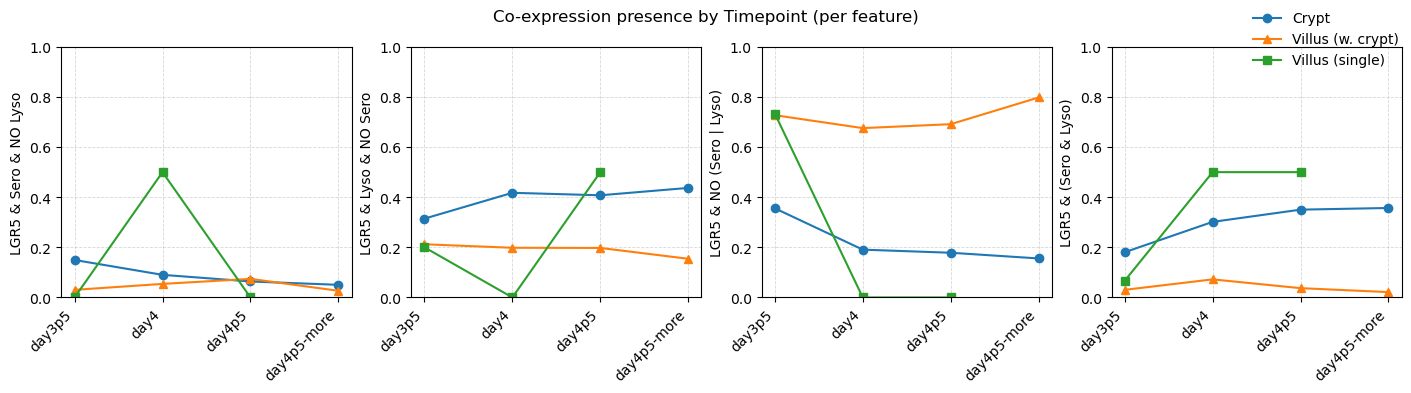

In [47]:
x = np.arange(len(timepoints))
n_cols = 4
n_rows = int(np.ceil(len(labels_cond) / n_cols))

fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3.5 * n_cols, 3.5 * n_rows),
        sharex=True, sharey=False,
        constrained_layout=True
    )

for i in range(len(labels_cond)):

    ax = axes[i]

    ax.plot(x, coexpression_crypt[:,i]/marker_pos_crypt[:,i_LGR5], marker='o', label='Crypt')
    ax.plot(x, coexpression_villus[:,i]/marker_pos_villus[:,i_LGR5], marker='^', label='Villus (w. crypt)')
    ax.plot(x, coexpression_single[:,i]/marker_pos_single[:,i_LGR5], marker='s', label='Villus (single)')

    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)

    # x ticks = timepoints (rotate for readability)
    ax.set_xticks(x)
    ax.set_xticklabels(timepoints, rotation=45, ha="right")
    ax.set_ylabel(labels_cond[i])
    ax.set_ylim([0, 1])

    # Single, figure-level legend
    # (grab handles/labels from the first visible axis)

    handles, labels = axes[i].get_legend_handles_labels()


fig.legend(handles, labels, loc="upper right", ncol=1, frameon=False)
fig.suptitle("Co-expression presence by Timepoint (per feature)", y=1.08, fontsize=12)
plt.show()

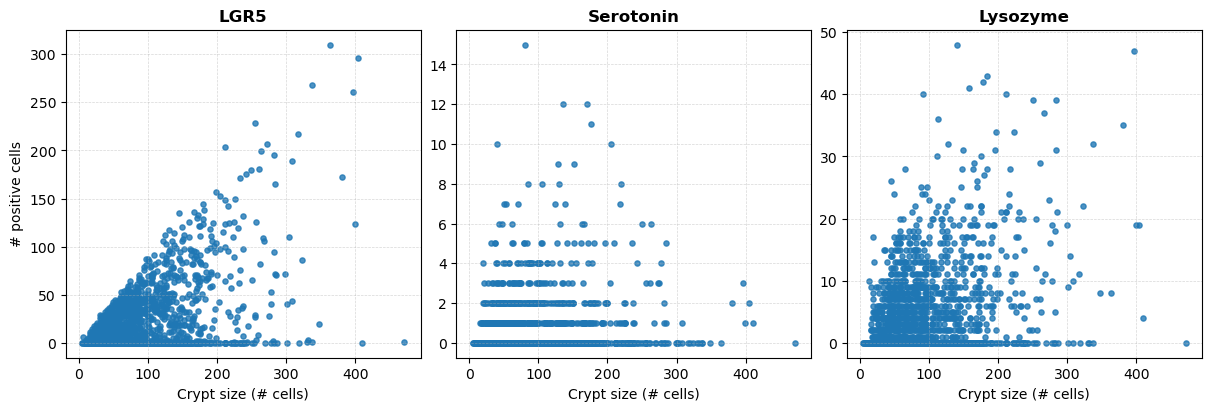

In [48]:
def get_marker_counts_per_patch(patch, markers):
    idx = np.fromiter(patch, dtype=np.int64)
    num_pos_cells = np.sum(markers[idx, :], axis=0).astype(np.int64)
    num_cells = len(idx)
    return num_pos_cells, num_cells

def split_villus_by_organoid(villus_patches, crypt_patches):
    """Return (villus_only, villus_with_crypts) as two lists of sets."""
    if crypt_patches and len(crypt_patches) > 0:
        return [], list(villus_patches)
    else:
        return list(villus_patches), []

# --- configuration ---
min_positive = 2

# --- aggregate across all timepoints/organoids ---
num_pos_cells_crypt_all = []
num_cells_crypt_all = []

for tp, d in results.items(): # loop over timepoints
    graphs_all   = d.get("cell_graphs_all", [])
    crypts_all   = d.get("crypts_all",   [])
    villus_all   = d.get("villus_all",   [])

    if isinstance(crypts_all, np.ndarray): crypts_all = crypts_all.tolist()

    n_items = len(graphs_all)
    for i in range(n_items): # loop over organoids in timepoint
        markers = np.array([graphs_all[i].nodes[n]["markers_bin"] for n in graphs_all[i].nodes])
        crypt_patches = _to_patch_list(crypts_all[i] if i < len(crypts_all) else None)

        # (OPTIONAL) filter out regions with too few cells
        # crypt_patches  = [p for p in crypt_patches  if len(p) >= min_cells]

        for patch in crypt_patches:
            num_pos_cells, num_cells = get_marker_counts_per_patch(patch, markers)
            
            num_cells_crypt_all.append(num_cells)
            num_pos_cells_crypt_all.append(num_pos_cells)


# Stack to (n_crypts, n_markers)
pos_mat = np.vstack([np.asarray(v, dtype=int) for v in num_pos_cells_crypt_all])  # each v is a vector per crypt
sizes   = np.asarray(num_cells_crypt_all, dtype=int)                               # (n_crypts,)

markers = [("LGR5", i_LGR5), ("Serotonin", i_Sero), ("Lysozyme", i_Lyso)]

fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True, sharex=True, sharey=False)

for ax, (name, idx) in zip(axes, markers):
    y = pos_mat[:, idx]
    ax.scatter(sizes, y, s=14, alpha=0.8)
    # y = x reference line
    ax.set_title(name, fontweight="bold")
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

axes[0].set_ylabel("# positive cells")
for ax in axes:
    ax.set_xlabel("Crypt size (# cells)")

plt.show()


## Spatially resolved marker composition in crypts

In [49]:
def coarsen_bins(bin_centers, counts, k):
    """
    Combine bins by summing every k consecutive bins.

    bin_centers: (n_bins,)
    counts: (..., n_bins)
    k: int, number of bins to combine

    Returns:
        bin_centers_coarse: (n_bins_coarse,)
        counts_coarse: (..., n_bins_coarse)
    """
    if k <= 1:
        return bin_centers, counts

    n_bins = bin_centers.shape[0]
    n_coarse = n_bins // k

    # truncate to full blocks of k
    trunc = n_coarse * k
    bin_centers_trunc = bin_centers[:trunc]
    counts_trunc = counts[..., :trunc]

    # reshape and sum
    new_shape = counts_trunc.shape[:-1] + (n_coarse, k)
    counts_block = counts_trunc.reshape(new_shape)
    counts_coarse = counts_block.sum(axis=-1)

    bin_centers_block = bin_centers_trunc.reshape(n_coarse, k)
    bin_centers_coarse = bin_centers_block.mean(axis=1)

    return bin_centers_coarse, counts_coarse


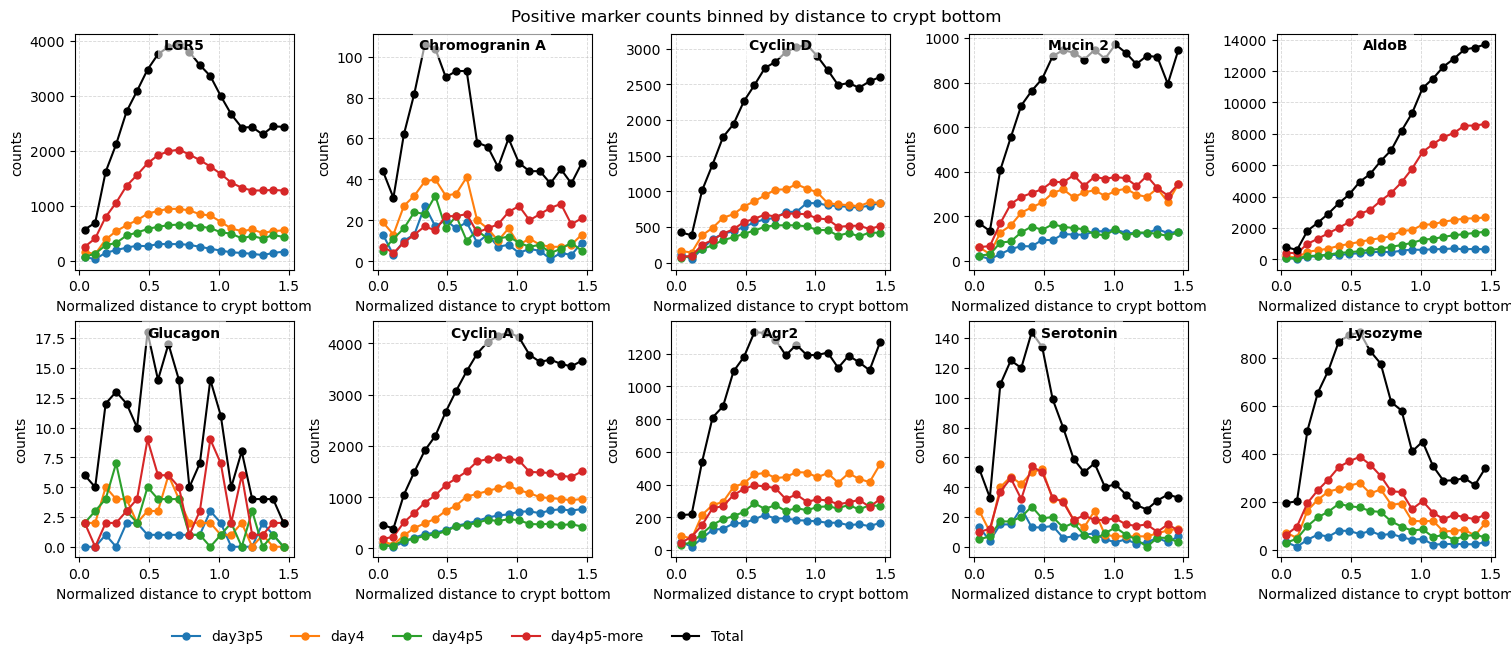

In [50]:
# --------- CONFIG ---------
k = 4   # number of fine bins to combine (adjust this!)
# --------------------------

M = len(marker_names)
n_cols = 5
n_rows = int(np.ceil(M / n_cols))

# coarsen bins for plotting
bin_centers_coarse, num_pos_per_bin_coarse = coarsen_bins(
    bin_centers,
    num_pos_per_bin,   # shape (n_tp, M, n_bins)
    k,
)


fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3 * n_cols, 3 * n_rows),
        sharex=False, sharey=False,
        constrained_layout=True
    )

for i in range(M):
    r, c = divmod(i, n_cols)
    ax = axes[r, c]

    ax.plot(bin_centers_coarse, num_pos_per_bin_coarse[:,i,:].T, marker='o', linewidth=1.5, markersize=5)
    ax.plot(bin_centers_coarse, np.sum(num_pos_per_bin_coarse[:,i,:], axis=0), marker='o', linewidth=1.5, markersize=5, color='k', label='Combined')

    ax.text(
        0.5, 0.98,                       # near the top-center of the axes
        marker_names[i],
        transform=ax.transAxes,
        ha="center", va="top",
        fontweight="bold", fontsize=10,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.6)  # optional halo for readability
    )
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
    ax.set_xlabel("Normalized distance to crypt bottom")
    ax.set_ylabel("counts")

# build legend labels: all timepoints + total
legend_labels = timepoints + ['Total']

# use handles from the first subplot
handles = [axes.flat[0].lines[j] for j in range(len(timepoints) + 1)]

# place legend below all subplots
fig.legend(handles, legend_labels,
           loc='upper right',
           ncol=min(6, len(legend_labels)),
           bbox_to_anchor=(0.5, -0.02),
           frameon=False)


plt.suptitle("Positive marker counts binned by distance to crypt bottom")
plt.show()


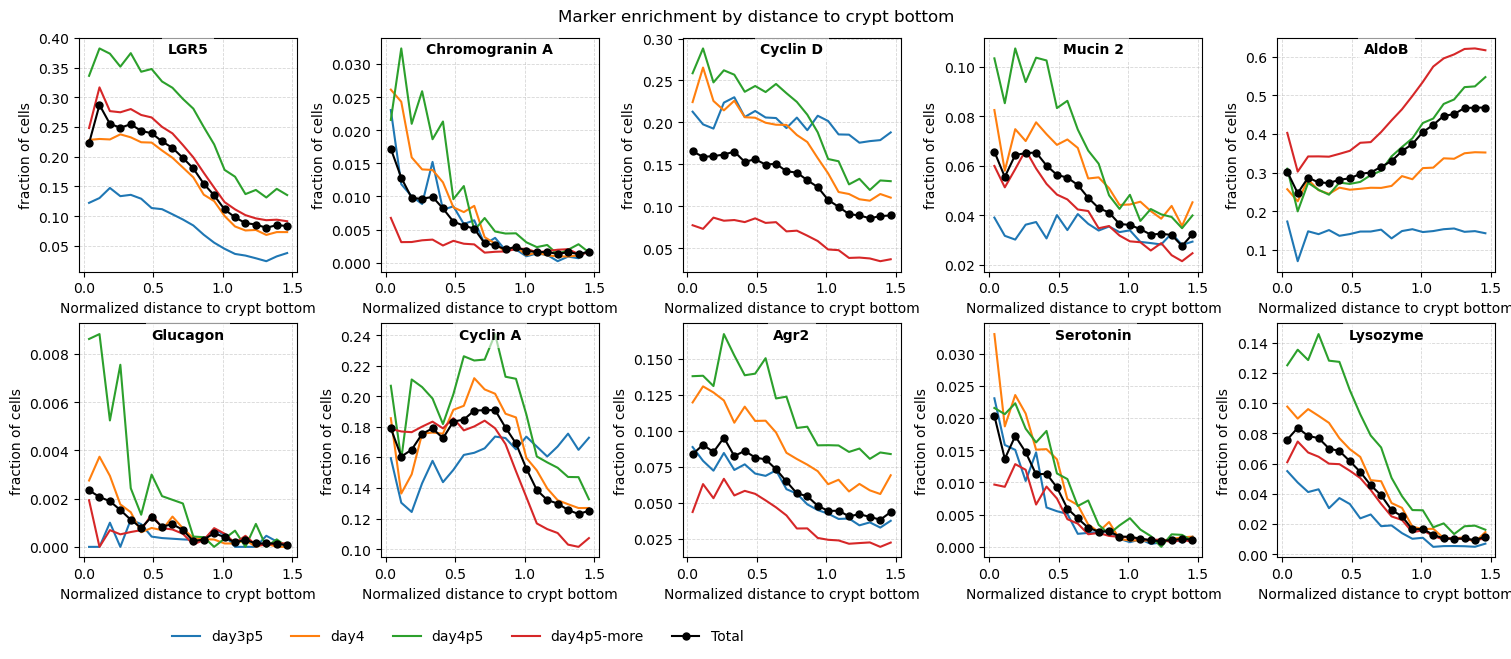

In [51]:
_, num_cells_per_bin_coarse = coarsen_bins(
    bin_centers,
    num_cells_per_bin,   # shape (n_tp, M, n_bins)
    k,
)


M = len(marker_names)
n_cols = 5
n_rows = int(np.ceil(M / n_cols))

fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3 * n_cols, 3 * n_rows),
        sharex=False, sharey=False,
        constrained_layout=True
    )

for i in range(M):
    r, c = divmod(i, n_cols)
    ax = axes[r, c]

    ax.plot(bin_centers_coarse, num_pos_per_bin_coarse[:,i,:].T/num_cells_per_bin_coarse.T, linewidth=1.5, markersize=5)
    ax.plot(bin_centers_coarse, np.sum(num_pos_per_bin_coarse[:,i,:], axis=0)/np.sum(num_cells_per_bin_coarse, axis=0), marker='o', linewidth=1.5, markersize=5, color='k', label='Combined')

    ax.text(
        0.5, 0.98,                       # near the top-center of the axes
        marker_names[i],
        transform=ax.transAxes,
        ha="center", va="top",
        fontweight="bold", fontsize=10,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.6)  # optional halo for readability
    )
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
    ax.set_xlabel("Normalized distance to crypt bottom")
    ax.set_ylabel("fraction of cells")

# build legend labels: all timepoints + total
legend_labels = timepoints + ['Total']

# use handles from the first subplot
handles = [axes.flat[0].lines[j] for j in range(len(timepoints) + 1)]

# place legend below all subplots
fig.legend(handles, legend_labels,
           loc='upper right',
           ncol=min(6, len(legend_labels)),
           bbox_to_anchor=(0.5, -0.02),
           frameon=False)


plt.suptitle("Marker enrichment by distance to crypt bottom")
plt.show()


## Plot crypt morphologies

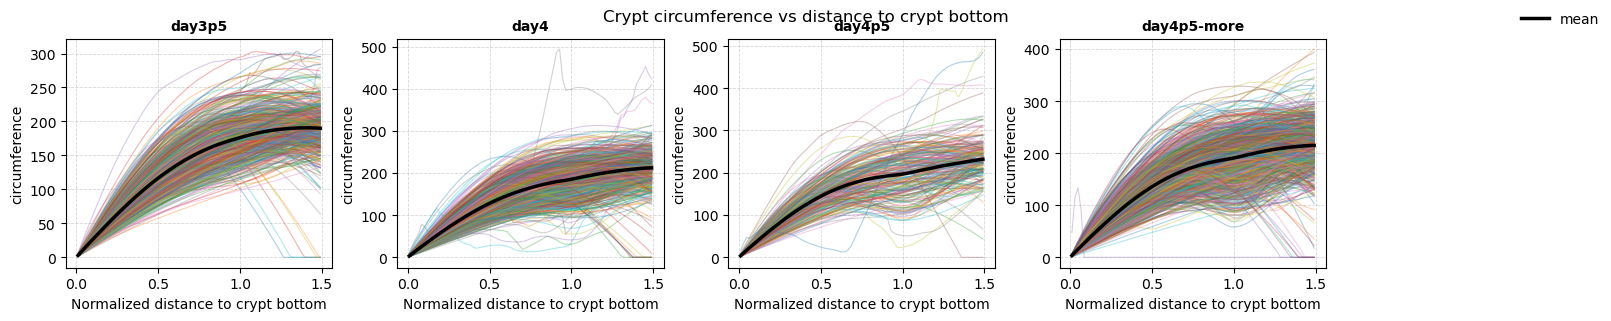

In [52]:
n_tp = len(timepoints)

n_cols = 5
n_rows = int(np.ceil(n_tp / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(3.2 * n_cols, 3.0 * n_rows),
    sharex=False, sharey=False,
    constrained_layout=True
)

axes = np.atleast_1d(axes).ravel()

for j, tp in enumerate(timepoints):
    ax = axes[j]

    C = np.asarray(crypt_circumferences_all[j])
    if C.size == 0:
        ax.text(0.5, 0.5, "no crypts", transform=ax.transAxes,
                ha="center", va="center", fontsize=10)
        ax.set_title(tp)
        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
        continue

    # individual crypt curves (thin)
    ax.plot(bin_centers, C.T, linewidth=0.8, alpha=0.35)

    # mean curve (thick)
    C_mean = np.nanmean(C, axis=0)
    ax.plot(bin_centers, C_mean, linewidth=2.5, color="k", label="mean")

    ax.set_title(tp, fontweight="bold", fontsize=10)
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
    ax.set_xlabel("Normalized distance to crypt bottom")
    ax.set_ylabel("circumference")

# turn off unused subplots
for k in range(n_tp, len(axes)):
    axes[k].axis("off")

# legend (only mean line)
fig.legend([axes[0].lines[-1]], ["mean"],
           loc="upper right",
           frameon=False)

plt.suptitle("Crypt circumference vs distance to crypt bottom", y=1.02)
plt.show()

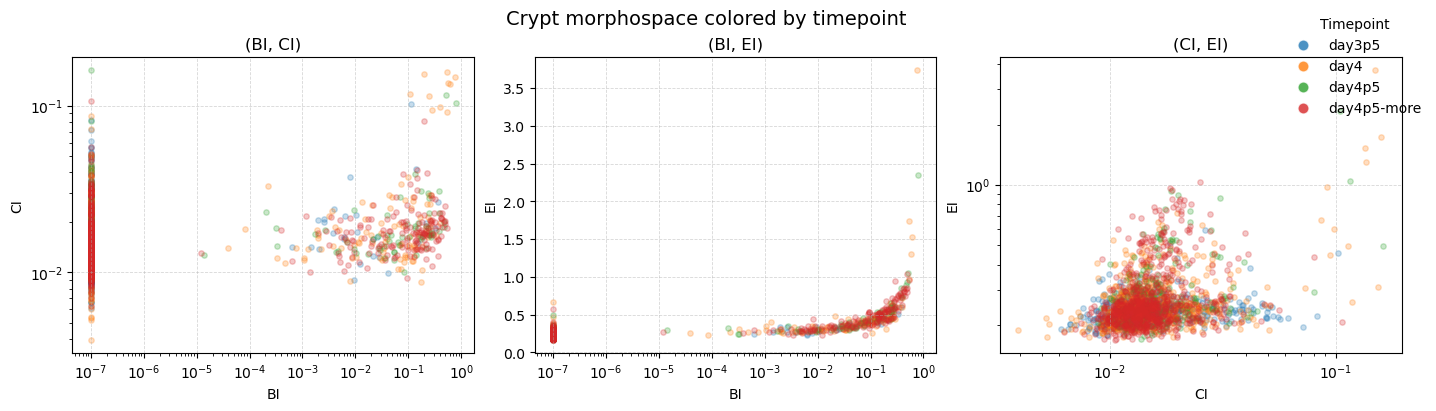

In [53]:
from matplotlib.lines import Line2D

# BI_all, CI_all, EI_all: lists per timepoint (each element = array of crypt values)
# timepoints: list of timepoint labels (same order as BI_all, CI_all, EI_all)

# ---- collect data per timepoint ----
data = []
for tp_idx, tp in enumerate(timepoints):
    BI_tp = np.asarray(BI_all[tp_idx], float).ravel()
    CI_tp = np.asarray(CI_all[tp_idx], float).ravel()
    EI_tp = np.asarray(EI_all[tp_idx], float).ravel()

    m = np.isfinite(BI_tp) & np.isfinite(CI_tp) & np.isfinite(EI_tp)
    if np.any(m):
        data.append((tp, BI_tp[m], CI_tp[m], EI_tp[m]))

# ---- colors for timepoints ----
cmap = plt.get_cmap("tab10")  # good for categorical timepoints
colors = {tp: cmap(i % 10) for i, tp in enumerate(timepoints)}

# ---- plot ----
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

for tp, BI_tp, CI_tp, EI_tp in data:
    col = colors[tp]

    # (BI, CI)
    axes[0].scatter(BI_tp+1e-7, CI_tp, s=15, alpha=0.25, color=col)

    # (BI, EI)
    axes[1].scatter(BI_tp+1e-7, EI_tp, s=15, alpha=0.25, color=col)

    # (CI, EI)
    axes[2].scatter(CI_tp, EI_tp, s=15, alpha=0.25, color=col)

# ---- formatting ----
axes[0].set_xlabel("BI")
axes[0].set_ylabel("CI")
axes[0].set_title("(BI, CI)")
# axes[0].set_xlim(0, 1)
# axes[0].set_ylim(0, 1)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].grid(True, linestyle="--", linewidth=0.6, alpha=0.5)

axes[1].set_xlabel("BI")
axes[1].set_ylabel("EI")
axes[1].set_title("(BI, EI)")
# axes[1].set_xlim(0, 1)
axes[1].set_xscale('log')
axes[1].grid(True, linestyle="--", linewidth=0.6, alpha=0.5)

axes[2].set_xlabel("CI")
axes[2].set_ylabel("EI")
axes[2].set_title("(CI, EI)")
# axes[2].set_xlim(0, 1)
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].grid(True, linestyle="--", linewidth=0.6, alpha=0.5)

# ---- legend ----
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label=str(tp),
           markerfacecolor=colors[tp], markersize=8, alpha=0.8)
    for tp in timepoints
]

fig.legend(
    handles=legend_handles,
    title="Timepoint",
    loc="upper right",
    bbox_to_anchor=(1.02, 1.0),
    frameon=False
)

plt.suptitle("Crypt morphospace colored by timepoint", fontsize=14)
plt.show()

In [57]:
import numpy as np

# ---- config ----
min_cells = 10        # adjust if you want to ignore tiny crypts
pos_threshold = 1    # marker_coexpression threshold

# marker indices
i_LGR5 = marker_names.index("LGR5")
i_Sero = marker_names.index("Serotonin")
i_Lyso = marker_names.index("Lysozyme")

# ---- output containers (flat across ALL crypts) ----
crypt_cat_idx = []      # int in {0,1,2,3} or -1
crypt_tp_idx  = []      # which timepoint (index)
crypt_org_idx = []      # which organoid within timepoint
crypt_patch_idx = []    # which crypt within organoid

for tp_idx, tp in enumerate(timepoints):
    d = results[tp]
    graphs_all = d.get("cell_graphs_all", [])
    crypts_all = d.get("crypts_all", [])

    if isinstance(crypts_all, np.ndarray):
        crypts_all = crypts_all.tolist()

    for org_idx in range(len(graphs_all)):
        G = graphs_all[org_idx]
        # markers per cell
        markers = np.asarray([G.nodes[n]["markers_bin"] for n in G.nodes], dtype=np.int64)

        crypt_patches = as_patch_list(crypts_all[org_idx] if org_idx < len(crypts_all) else None)
        if not crypt_patches:
            continue

        for p_idx, patch in enumerate(crypt_patches):
            patch = set(patch)
            # if len(patch) < min_cells:
            #     continue

            coexp = marker_coexpression(
                patch,
                markers,
                i_LGR5=i_LGR5,
                i_Sero=i_Sero,
                i_Lyso=i_Lyso,
                pos_threshold=pos_threshold,
            )  # (4,) int (0/1)

            # convert 4-vector -> single category index
            if np.sum(coexp) == 1:
                cat = int(np.argmax(coexp))   # 0..3
            else:
                cat = -1                      # none or ambiguous (multiple true)

            crypt_cat_idx.append(cat)
            crypt_tp_idx.append(tp_idx)
            crypt_org_idx.append(org_idx)
            crypt_patch_idx.append(p_idx)

crypt_cat_idx = np.asarray(crypt_cat_idx, dtype=int)
crypt_tp_idx  = np.asarray(crypt_tp_idx, dtype=int)
crypt_org_idx = np.asarray(crypt_org_idx, dtype=int)
crypt_patch_idx = np.asarray(crypt_patch_idx, dtype=int)

print("Assigned categories for", crypt_cat_idx.size, "crypts.")
print("Category counts:", {k: int(np.sum(crypt_cat_idx == k)) for k in [-1,0,1,2,3]})


Assigned categories for 2272 crypts.
Category counts: {-1: 1096, 0: 96, 1: 478, 2: 239, 3: 363}


N metrics: 2272
N cats:    2272


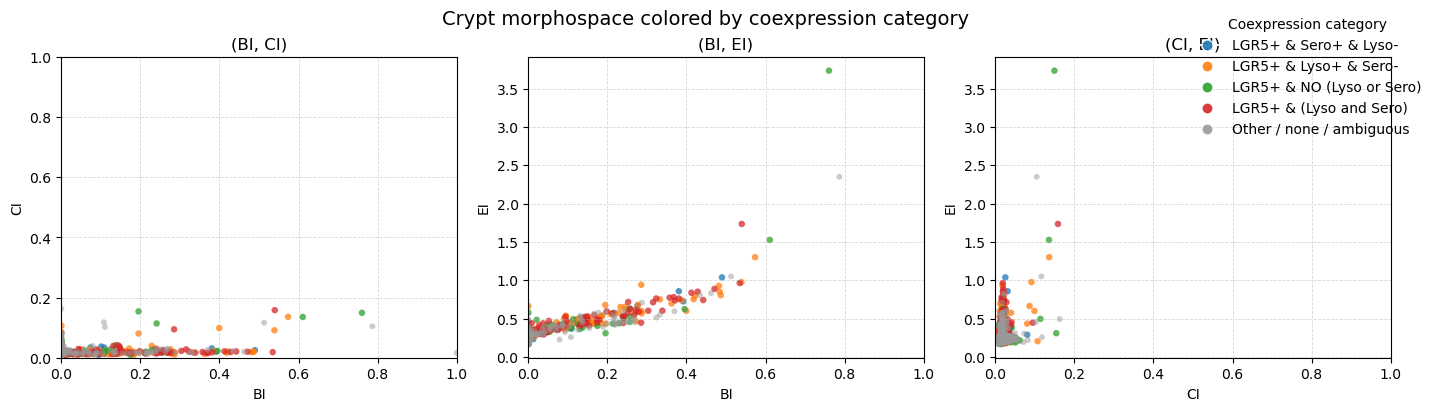

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

BI_flat = np.concatenate([np.asarray(x, float).ravel() for x in BI_all if len(x)])
CI_flat = np.concatenate([np.asarray(x, float).ravel() for x in CI_all if len(x)])
EI_flat = np.concatenate([np.asarray(x, float).ravel() for x in EI_all if len(x)])


cat_names = [
    "LGR5+ & Sero+ & Lyso-",
    "LGR5+ & Lyso+ & Sero-",
    "LGR5+ & NO (Lyso or Sero)",
    "LGR5+ & (Lyso and Sero)",
]
unknown_name = "Other / none / ambiguous"

cmap = plt.get_cmap("tab10")
cat_colors = {k: cmap(k) for k in range(4)}
cat_colors[-1] = (0.6, 0.6, 0.6, 0.35)

# ---- prepare vectors ----
BI = np.asarray(BI_flat, float).ravel() + 1e-7
CI = np.asarray(CI_flat, float).ravel()
EI = np.asarray(EI_flat, float).ravel()
cat = np.asarray(crypt_cat_idx, int).ravel()

print("N metrics:", len(BI_flat))
print("N cats:   ", len(crypt_cat_idx))


fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

pairs = [
    (BI, CI, "BI", "CI", "(BI, CI)"),
    (BI, EI, "BI", "EI", "(BI, EI)"),
    (CI, EI, "CI", "EI", "(CI, EI)"),
]

for ax, (x, y, xl, yl, title) in zip(axes, pairs):
    # plot categories 0..3
    for k in range(4):
        mk = (cat == k)
        if np.any(mk):
            ax.scatter(x[mk], y[mk], s=22, alpha=0.75, color=cat_colors[k], edgecolors="none")
    # plot unknown / ambiguous
    mu = (cat == -1)
    if np.any(mu):
        ax.scatter(x[mu], y[mu], s=18, alpha=0.5, color=cat_colors[-1], edgecolors="none")

    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(title)
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)

    # if xl in ("BI", "CI"):
    #     ax.set_xlim(0, 1)
    # if yl in ("BI", "CI"):
    #     ax.set_ylim(0, 1)

    ax.set_xscale('log')
    ax.set_yscale('log')

legend_handles = [
    Line2D([0], [0], marker='o', color='w', label=cat_names[k],
           markerfacecolor=cat_colors[k], markersize=8, alpha=0.9)
    for k in range(4)
]
legend_handles.append(
    Line2D([0], [0], marker='o', color='w', label=unknown_name,
           markerfacecolor=cat_colors[-1], markersize=8, alpha=0.9)
)

fig.legend(
    handles=legend_handles,
    title="Coexpression category",
    loc="upper right",
    bbox_to_anchor=(1.02, 1.0),
    frameon=False
)

plt.suptitle("Crypt morphospace colored by coexpression category", fontsize=14)
plt.show()


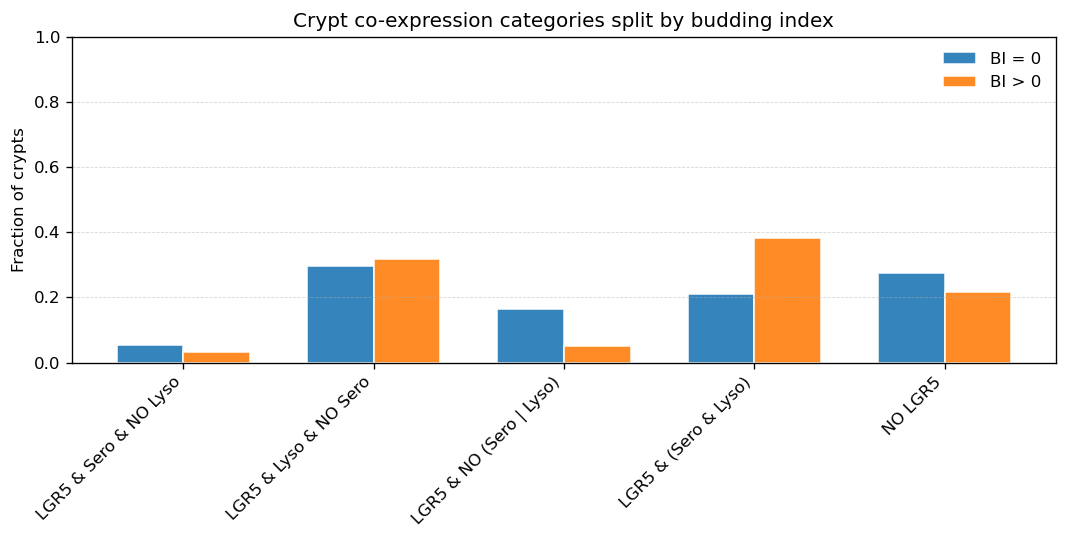

In [ ]:
labels_cond = [
    "LGR5 & Sero & NO Lyso",
    "LGR5 & Lyso & NO Sero",
    "LGR5 & NO (Sero | Lyso)",
    "LGR5 & (Sero & Lyso)",
    "NO LGR5",
]

BI = np.asarray(BI_flat, float)
cat = np.asarray(crypt_cat_idx, int)

# valid mask
m = np.isfinite(BI)
BI = BI[m]
cat = cat[m]


# split crypts
mask_BI0 = (BI == 0)
mask_BIpos = (BI > 0)

def category_fractions(mask):
    cats = cat[mask]
    n_total = len(cats)

    if n_total == 0:
        return np.zeros(5)

    fracs = np.zeros(5)

    # categories 0..3 = LGR5+ coexpression types
    for k in range(4):
        fracs[k] = np.sum(cats == k) / n_total

    # category 4 = NO LGR5 (cat == -1)
    fracs[4] = np.sum(cats == -1) / n_total

    return fracs

frac_BI0 = category_fractions(mask_BI0)
frac_BIpos = category_fractions(mask_BIpos)

# --- Plot grouped bars ---
x = np.arange(len(labels_cond))
w = 0.35

plt.figure(figsize=(max(9, 0.6*len(labels_cond)), 4.6), dpi=120)

plt.bar(x - w/2, frac_BI0, width=w, label="BI = 0", edgecolor="white", alpha=0.9)
plt.bar(x + w/2, frac_BIpos, width=w, label="BI > 0", edgecolor="white", alpha=0.9)

plt.xticks(x, labels_cond, rotation=45, ha="right")
plt.ylim(0, 1)
plt.ylabel("Fraction of crypts")
plt.title("Crypt co-expression categories split by budding index")
plt.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


Total crypts (raw): 212
Dropping curves:
  nonfinite: 0
  all_zero : 0
  >25% zeros: 0
  total dropped: 0
Total crypts (kept): 212
Dropping due to nonfinite features: 0
Final crypt count for clustering: 212
Silhouette score: 0.4587682184346808


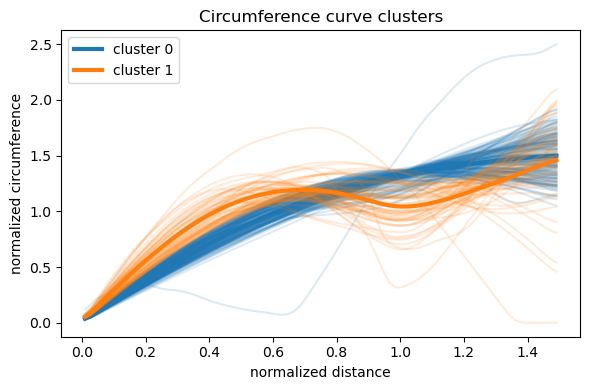

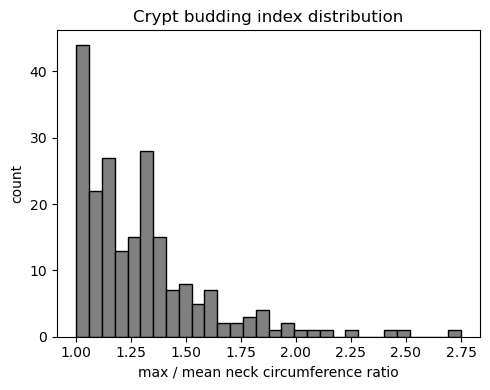

Budding index summary:
  mean = 1.2989670579297998
  std  = 0.290672237558185
  min  = 1.0027641594763579
  max  = 2.7488498853439305


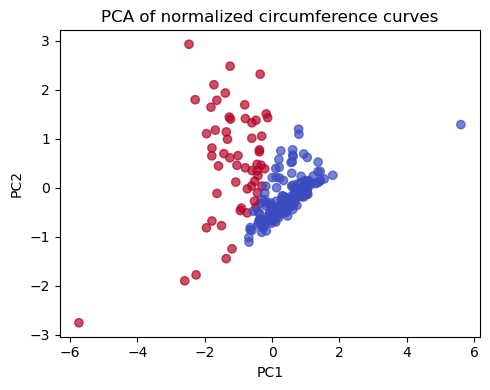

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# ============================================================
# 1) Collect curves across timepoints
# ============================================================

curves = []
curve_meta = []  # (timepoint_idx, crypt_idx)

for tp_idx, C_tp in enumerate(crypt_circumferences_all):
    C_tp = np.asarray(C_tp)
    if C_tp.size == 0:
        continue
    for k in range(C_tp.shape[0]):
        curves.append(C_tp[k])
        curve_meta.append((tp_idx, k))

curves = np.asarray(curves, dtype=float)  # (N_crypts, n_bins)
print("Total crypts (raw):", curves.shape[0])

s = bin_centers

# ============================================================
# 2) Basic cleaning: remove pathological curves
# ============================================================

# A curve is "bad" if:
# - any non-finite
# - too many near-zeros (likely "no contour" bins)
# - nearly all zeros (completely invalid)
eps0 = 1e-10
nonfinite = ~np.isfinite(curves).all(axis=1)
frac_zero = np.mean(curves <= eps0, axis=1)
all_zero  = np.all(curves <= eps0, axis=1)

# tweak thresholds if you want
bad = nonfinite | all_zero | (frac_zero > 0.25)

print("Dropping curves:")
print("  nonfinite:", int(np.sum(nonfinite)))
print("  all_zero :", int(np.sum(all_zero)))
print("  >25% zeros:", int(np.sum(frac_zero > 0.25)))
print("  total dropped:", int(np.sum(bad)))

curves = curves[~bad]
curve_meta = [m for m, keep in zip(curve_meta, ~bad) if keep]

print("Total crypts (kept):", curves.shape[0])

# Optional: lift tiny values away from 0 (prevents division blowups)
curves = np.maximum(curves, eps0)

# ============================================================
# 3) Normalize + smooth (shape-only)
# ============================================================

curves_norm = curves / np.nanmean(curves, axis=1, keepdims=True)
curves_norm = gaussian_filter1d(curves_norm, sigma=1.0, axis=1)

# ============================================================
# 4) Feature extraction (safe denominators)
# ============================================================

def extract_features(curve, eps=1e-8):
    bottom = float(np.mean(curve[s < 0.2]))
    neck   = float(np.mean(curve[(s > 0.8) & (s < 1.0)]))

    bottom = max(bottom, eps)
    neck   = max(neck, eps)

    bulge_amp    = float(np.max(curve) / bottom)
    constriction = float(neck / bottom)

    idx = np.where((s > 0.6) & (s < 1.0))[0]
    if idx.size >= 2:
        slope = float(np.polyfit(s[idx], curve[idx], 1)[0])
        curvature = float(np.mean(np.gradient(np.gradient(curve[idx]))))
    else:
        slope = np.nan
        curvature = np.nan

    return np.array([constriction, bulge_amp, slope, curvature], dtype=float)

X_feat = np.vstack([extract_features(c) for c in curves_norm])

# remove rows with nan/inf (e.g. from tiny idx ranges etc)
good_feat = np.isfinite(X_feat).all(axis=1)
print("Dropping due to nonfinite features:", int(np.sum(~good_feat)))

curves_norm = curves_norm[good_feat]
X_feat = X_feat[good_feat]
curve_meta = [m for m, keep in zip(curve_meta, good_feat) if keep]

print("Final crypt count for clustering:", X_feat.shape[0])

# ============================================================
# 5) Cluster (bulged vs budded)
# ============================================================

X = StandardScaler().fit_transform(X_feat)
kmeans = KMeans(n_clusters=2, random_state=0)
labels = kmeans.fit_predict(X)
print("Silhouette score:", silhouette_score(X, labels))

# ============================================================
# 6) Plot clusters (curves)
# ============================================================

plt.figure(figsize=(6, 4))
for k in [0, 1]:
    cluster_curves = curves_norm[labels == k]
    plt.plot(s, cluster_curves.T, color=f"C{k}", alpha=0.15)
    plt.plot(s, cluster_curves.mean(axis=0), color=f"C{k}", linewidth=3, label=f"cluster {k}")
plt.xlabel("normalized distance")
plt.ylabel("normalized circumference")
plt.title("Circumference curve clusters")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 7) Budding index = max / mean(neck) (safe)
# ============================================================

neck_mask = (s > 0.8) & (s < 1.0)
max_circ = np.max(curves_norm, axis=1)
mean_neck = np.mean(curves_norm[:, neck_mask], axis=1)
mean_neck = np.maximum(mean_neck, 1e-8)

budding_index = max_circ / mean_neck

plt.figure(figsize=(5, 4))
plt.hist(budding_index, bins=30, color="gray", edgecolor="black")
plt.xlabel("max / mean neck circumference ratio")
plt.ylabel("count")
plt.title("Crypt budding index distribution")
plt.tight_layout()
plt.show()

print("Budding index summary:")
print("  mean =", float(np.mean(budding_index)))
print("  std  =", float(np.std(budding_index)))
print("  min  =", float(np.min(budding_index)))
print("  max  =", float(np.max(budding_index)))

# ============================================================
# 8) Optional PCA sanity check
# ============================================================

pca = PCA(n_components=3)
X_pca = pca.fit_transform(curves_norm)

plt.figure(figsize=(5, 4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="coolwarm", alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of normalized circumference curves")
plt.tight_layout()
plt.show()


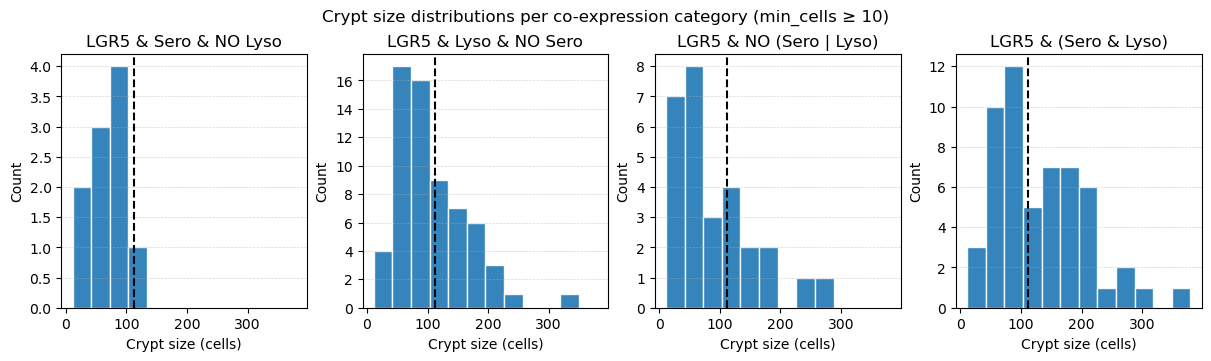

all_curv_mean: 157 finite values min/max: (np.float64(-0.20709893107414246), np.float64(0.4266149699687958))


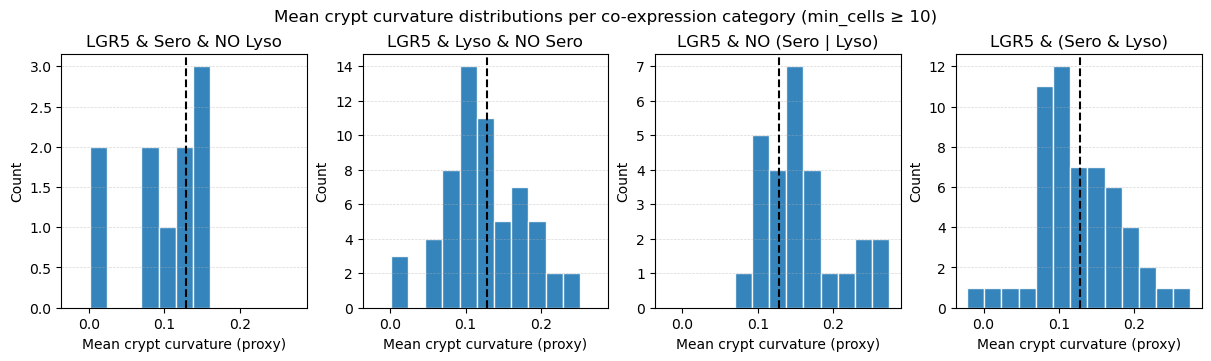

all_curv_std: 157 finite values min/max: (np.float64(0.03321155160665512), np.float64(0.48937496542930603))


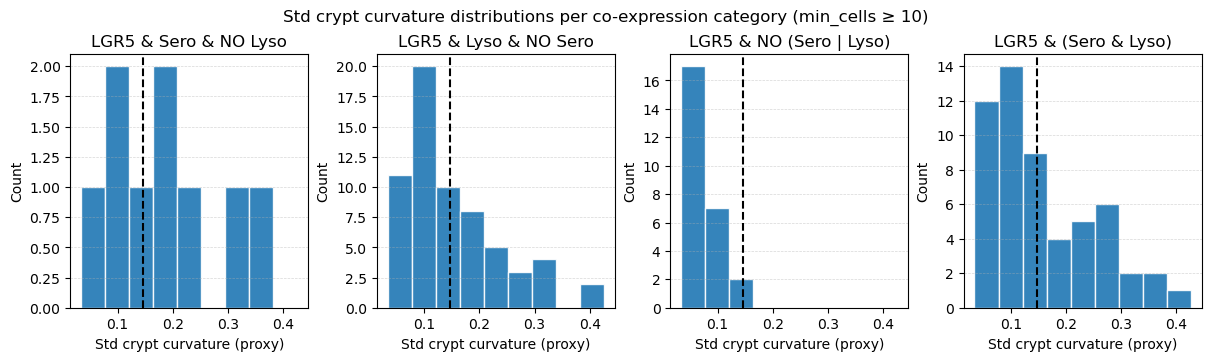

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def hks_to_curv_proxy_single_t(hks_col, t, d=2):
    """
    Convert a single HKS column (N,) at diffusion time t to a curvature-like target:
      Y_t = (6/t) * [ (4πt)^{d/2} * HKS_t - 1 ]  ~  Gaussian curvature
    Returns float32 (N,).
    """
    h = np.asarray(hks_col, dtype=np.float64).reshape(-1)
    t = float(t)
    Y = (6.0 / t) * ((4.0 * np.pi * t) ** (d / 2.0) * h - 1.0)
    return Y.astype(np.float32)

def as_patch_list(x):
    """Normalize to list[set[int]]: None -> [], set -> [set], list/tuple -> list of sets."""
    if x is None:
        return []
    if isinstance(x, set):
        return [x]
    if isinstance(x, (list, tuple)):
        return [set(p) for p in x if p is not None and len(p) > 0]
    return []

# --- Co-expression condition labels (order must match marker_coexpression output) ---
labels_cond = [
    "LGR5 & Sero & NO Lyso",
    "LGR5 & Lyso & NO Sero",
    "LGR5 & NO (Sero | Lyso)",
    "LGR5 & (Sero & Lyso)",
]

marker_names = ['LGR5', 'Chromogranin A', 'Cyclin D', 'Mucin 2', 'AldoB',
                'Glucagon', 'Cyclin A', 'Agr2', 'Serotonin', 'Lysozyme']

# --- configuration ---
min_cells = 10
pos_threshold = 1

# --- Collect crypt sizes per co-expression category ---
size_by_cond      = [[] for _ in range(len(labels_cond))]
mean_curv_by_cond = [[] for _ in range(len(labels_cond))]
std_curv_by_cond  = [[] for _ in range(len(labels_cond))]

for tp, d in results.items():  # loop over timepoints
    crypts_all = d.get("crypts_all", [])
    Gs         = d.get("cell_graphs_all", [])
    label_uids = d.get("label_uid", [])

    if isinstance(crypts_all, np.ndarray):
        crypts_all = crypts_all.tolist()

    if not Gs:
        continue

    # marker names should be available in your notebook scope; if not, try pull from graph
    # marker_names = ... (list[str])
    i_LGR5 = marker_names.index("LGR5")
    i_Sero = marker_names.index("Serotonin")
    i_Lyso = marker_names.index("Lysozyme")

    for i in range(len(Gs)):  # loop over organoids
        G = Gs[i]
        if G is None:
            continue

        crypt_patches = as_patch_list(crypts_all[i] if i < len(crypts_all) else None)
        if not crypt_patches:
            continue

        # (N_cells, n_markers)
        n_cells = G.number_of_nodes()
        markers = np.asarray([G.nodes[n]["markers_bin"] for n in range(n_cells)], dtype=int)

        # HKS is stored per cell in graph nodes (assumes key 'hks' exists)
        # HKS_cell: (N_cells, T)
        HKS_cell = np.vstack([np.asarray(G.nodes[n]["hks"], dtype=float) for n in range(n_cells)])

        # filter crypts by minimum size
        crypt_patches = [p for p in crypt_patches if len(p) >= min_cells]

        for patch in crypt_patches:
            patch = set(patch)
            crypt_size = int(len(patch))
            idx = np.fromiter(patch, dtype=int)

            # curvature proxy from HKS at a single time index (here: column 0, t=1.0)
            curv_crypt = hks_to_curv_proxy_single_t(HKS_cell[idx, 0], t=1.0)

            # co-expression vector (4 categories)
            coexp = marker_coexpression(
                patch, markers, i_LGR5, i_Sero, i_Lyso, pos_threshold=pos_threshold
            )

            for ci in range(len(labels_cond)):
                if coexp[ci] == 1:
                    size_by_cond[ci].append(crypt_size)
                    mean_curv_by_cond[ci].append(float(np.mean(curv_crypt)))
                    std_curv_by_cond[ci].append(float(np.std(curv_crypt)))

# --- Prepare shared bins across all categories for comparability ---
all_sizes = np.concatenate([np.asarray(s, dtype=int) for s in size_by_cond if len(s) > 0]) \
    if any(len(s) > 0 for s in size_by_cond) else np.array([], dtype=int)
all_curv_mean = np.concatenate([np.asarray(s, dtype=float) for s in mean_curv_by_cond if len(s) > 0]) \
    if any(len(s) > 0 for s in mean_curv_by_cond) else np.array([], dtype=float)
all_curv_std = np.concatenate([np.asarray(s, dtype=float) for s in std_curv_by_cond if len(s) > 0]) \
    if any(len(s) > 0 for s in std_curv_by_cond) else np.array([], dtype=float)

# ----------------------------
# Plot: crypt size distributions
# ----------------------------
if all_sizes.size > 0:
    bins = np.histogram_bin_edges(all_sizes, bins="auto")

    fig, axes = plt.subplots(1, len(labels_cond), figsize=(12, 3.5), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    for ci in range(len(labels_cond)):
        ax = axes[ci]
        ax.hist(size_by_cond[ci], bins=bins, edgecolor="white", alpha=0.9)
        ax.set_title(labels_cond[ci])
        ax.set_xlabel("Crypt size (cells)")
        ax.set_ylabel("Count")
        ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
        ax.axvline(np.mean(all_sizes), color="k", linestyle="--")

    fig.suptitle(f"Crypt size distributions per co-expression category (min_cells ≥ {min_cells})")
    plt.show()
else:
    print("No crypt sizes collected (all_sizes empty).")


import numpy as np
import matplotlib.pyplot as plt

def _finite_concat(list_of_lists):
    """Concatenate lists -> 1D float array, keep only finite entries."""
    x = np.concatenate([np.asarray(a, dtype=float) for a in list_of_lists if len(a) > 0]) \
        if any(len(a) > 0 for a in list_of_lists) else np.array([], dtype=float)
    return x[np.isfinite(x)]

def _robust_bins(x, bins="auto", clip_q=(1, 99)):
    """
    Compute histogram bins robustly by clipping extremes before choosing bin edges.
    """
    if x.size == 0:
        return None
    lo, hi = np.percentile(x, clip_q)
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        # fallback
        lo, hi = np.min(x), np.max(x)
        if hi <= lo:
            hi = lo + 1e-6
    x_clip = x[(x >= lo) & (x <= hi)]
    if x_clip.size < 5:
        x_clip = x  # fallback
    return np.histogram_bin_edges(x_clip, bins=bins)

# =========================
# Curvature hist: MEAN
# =========================
all_curv_mean = _finite_concat(mean_curv_by_cond)
print("all_curv_mean:", all_curv_mean.size, "finite values",
      "min/max:", (np.min(all_curv_mean), np.max(all_curv_mean)) if all_curv_mean.size else None)

if all_curv_mean.size > 0:
    bins = _robust_bins(all_curv_mean, bins="auto", clip_q=(1, 99))

    fig, axes = plt.subplots(1, len(labels_cond), figsize=(12, 3.5), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    for ci in range(len(labels_cond)):
        ax = axes[ci]
        x = np.asarray(mean_curv_by_cond[ci], dtype=float)
        x = x[np.isfinite(x)]
        ax.hist(x, bins=bins, edgecolor="white", alpha=0.9)
        ax.set_title(labels_cond[ci])
        ax.set_xlabel("Mean crypt curvature (proxy)")
        ax.set_ylabel("Count")
        ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
        ax.axvline(np.mean(all_curv_mean), color="k", linestyle="--")

    fig.suptitle(f"Mean crypt curvature distributions per co-expression category (min_cells ≥ {min_cells})")
    plt.show()
else:
    print("No finite mean curvatures collected.")

# =========================
# Curvature hist: STD
# =========================
all_curv_std = _finite_concat(std_curv_by_cond)
print("all_curv_std:", all_curv_std.size, "finite values",
      "min/max:", (np.min(all_curv_std), np.max(all_curv_std)) if all_curv_std.size else None)

if all_curv_std.size > 0:
    bins = _robust_bins(all_curv_std, bins="auto", clip_q=(1, 99))

    fig, axes = plt.subplots(1, len(labels_cond), figsize=(12, 3.5), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    for ci in range(len(labels_cond)):
        ax = axes[ci]
        x = np.asarray(std_curv_by_cond[ci], dtype=float)
        x = x[np.isfinite(x)]
        ax.hist(x, bins=bins, edgecolor="white", alpha=0.9)
        ax.set_title(labels_cond[ci])
        ax.set_xlabel("Std crypt curvature (proxy)")
        ax.set_ylabel("Count")
        ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
        ax.axvline(np.mean(all_curv_std), color="k", linestyle="--")

    fig.suptitle(f"Std crypt curvature distributions per co-expression category (min_cells ≥ {min_cells})")
    plt.show()
else:
    print("No finite std curvatures collected.")


# # ----------------------------
# # Plot: mean curvature distributions
# # ----------------------------
# if all_curv_mean.size > 0:
#     bins = np.histogram_bin_edges(all_curv_mean, bins="auto")

#     fig, axes = plt.subplots(1, len(labels_cond), figsize=(12, 3.5), constrained_layout=True)
#     axes = np.atleast_1d(axes).ravel()

#     for ci in range(len(labels_cond)):
#         print(mean_curv_by_cond[ci])

#         ax = axes[ci]
#         ax.hist(mean_curv_by_cond[ci], bins=bins, edgecolor="white", alpha=0.9)
#         ax.set_title(labels_cond[ci])
#         ax.set_xlabel("Mean crypt curvature (proxy)")
#         ax.set_ylabel("Count")
#         ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
#         ax.axvline(np.mean(all_curv_mean), color="k", linestyle="--")

#     fig.suptitle(f"Mean crypt curvature distributions per co-expression category (min_cells ≥ {min_cells})")
#     plt.show()
# else:
#     print("No curvature means collected (all_curv_mean empty).")

# # ----------------------------
# # Plot: std curvature distributions
# # ----------------------------
# if all_curv_std.size > 0:
#     bins = np.histogram_bin_edges(all_curv_std, bins="auto")

#     fig, axes = plt.subplots(1, len(labels_cond), figsize=(12, 3.5), constrained_layout=True)
#     axes = np.atleast_1d(axes).ravel()

#     for ci in range(len(labels_cond)):
#         ax = axes[ci]
#         ax.hist(std_curv_by_cond[ci], bins=bins, edgecolor="white", alpha=0.9)
#         ax.set_title(labels_cond[ci])
#         ax.set_xlabel("Std crypt curvature (proxy)")
#         ax.set_ylabel("Count")
#         ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
#         ax.axvline(np.mean(all_curv_std), color="k", linestyle="--")

#     fig.suptitle(f"Std crypt curvature distributions per co-expression category (min_cells ≥ {min_cells})")
#     plt.show()
# else:
#     print("No curvature stds collected (all_curv_std empty).")


/home/fmoller/miniforge3/envs/SphericalHarmonics/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



Built feature matrix X: (212, 212)
Finite BI: 1.0  | categories: {-1: 55, 0: 10, 1: 64, 2: 28, 3: 55}


/home/fmoller/miniforge3/envs/SphericalHarmonics/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



UMAP embedding: (212, 2)


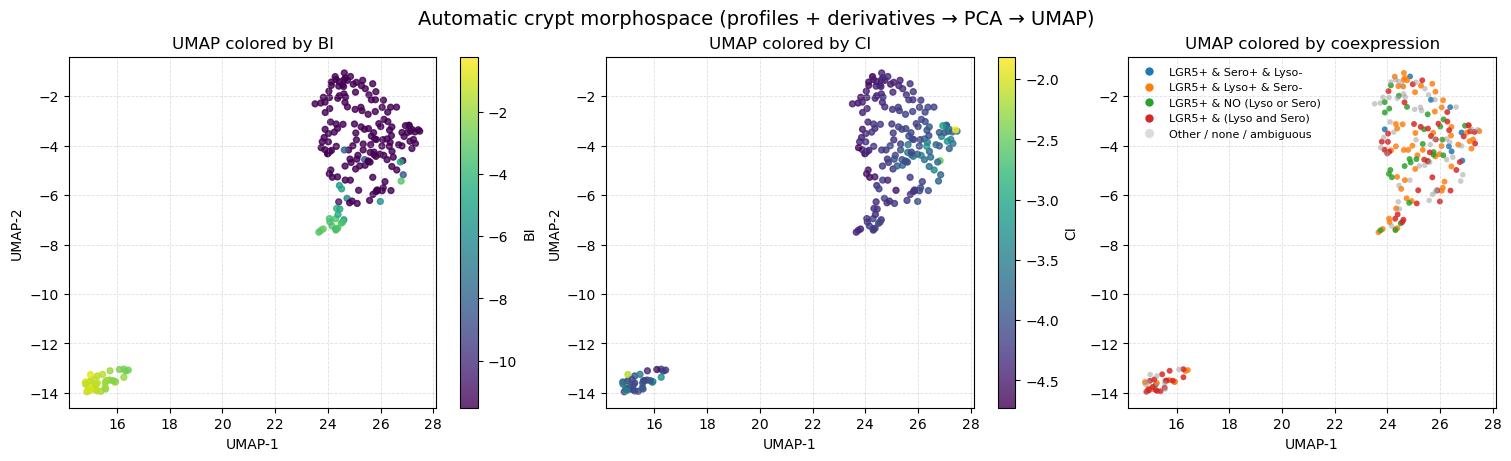

In [ ]:
# ============================================================
# Automatic morphospace from crypt profiles:
#   C'(s)=C(s)/C(1) on s∈[0,1]
#   σ'(s)=σ(s)/μ(s) on s∈[0,1]
# Features: profiles + 1st/2nd derivatives (after smoothing)
# Pipeline: Standardize -> PCA -> UMAP
# Plots: UMAP colored by BI, coexpression category, timepoint
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import umap  # pip install umap-learn
from matplotlib.lines import Line2D

from scipy.signal import savgol_filter
import numpy as np

def _profile_features_fixed_grid(s_grid, y, window=9, poly=3):
    """
    Return [y_smooth, dy/ds, d2y/ds2] on a FIXED s_grid (same length for all crypts).
    - Interpolates y onto s_grid if needed.
    - Fills NaNs by interpolation.
    - Applies SavGol smoothing then finite-difference derivatives.

    s_grid: (N,) fixed grid (e.g. s01)
    y:      (N,) values on the same grid (may contain NaNs)
    """
    s_grid = np.asarray(s_grid, float)
    y = np.asarray(y, float)

    if s_grid.ndim != 1 or y.ndim != 1 or s_grid.size != y.size:
        raise ValueError("s_grid and y must be 1D and the same length.")

    # require at least a few finite points
    m = np.isfinite(y)
    if np.sum(m) < 5:
        return None

    # fill NaNs by interpolation on the fixed grid
    y_fill = y.copy()
    y_fill[~m] = np.interp(s_grid[~m], s_grid[m], y[m])

    # SavGol params (ensure valid)
    wl = int(window)
    if wl % 2 == 0:
        wl += 1
    wl = min(wl, s_grid.size if s_grid.size % 2 == 1 else s_grid.size - 1)
    wl = max(wl, 5)
    po = int(poly)
    po = min(po, wl - 2)

    ys = savgol_filter(y_fill, window_length=wl, polyorder=po, mode="interp")

    dy = np.gradient(ys, s_grid)
    d2y = np.gradient(dy, s_grid)

    return np.concatenate([ys, dy, d2y])



def _profile_features_nosmooth(s_grid, y):
    """
    Return [y, dy/ds, d2y/ds2] on a fixed grid WITHOUT smoothing.

    s_grid: (N,) fixed s-grid (e.g. s01)
    y:      (N,) values on the same grid (may contain NaNs)
    """
    s_grid = np.asarray(s_grid, float)
    y = np.asarray(y, float)

    if s_grid.ndim != 1 or y.ndim != 1 or s_grid.size != y.size:
        raise ValueError("s_grid and y must be 1D and the same length.")

    # require enough finite points
    m = np.isfinite(y)
    if np.sum(m) < 5:
        return None

    # fill NaNs by linear interpolation on the fixed grid
    y_fill = y.copy()
    y_fill[~m] = np.interp(s_grid[~m], s_grid[m], y[m])

    # first derivative
    dy = np.gradient(y_fill, s_grid)

    # second derivative
    d2y = np.gradient(dy, s_grid)

    return np.concatenate([y_fill, dy])


# ----------------------------
# Helper: robust y(s=1)
# ----------------------------
def _value_at_1(s, y, target=1.0):
    s = np.asarray(s, float)
    y = np.asarray(y, float)
    m = np.isfinite(s) & np.isfinite(y)
    if np.sum(m) < 2:
        return np.nan
    s0 = s[m]; y0 = y[m]
    o = np.argsort(s0)
    s0 = s0[o]; y0 = y0[o]
    if target <= s0[0]:
        return float(y0[0])
    if target >= s0[-1]:
        return float(y0[-1])
    return float(np.interp(target, s0, y0))


# ----------------------------
# Helper: build features for one profile
# ----------------------------
def _profile_features(s, y, window=9, poly=3):
    """
    Smooth y(s) with SavGol, then return [y_smooth, dy/ds, d2y/ds2] concatenated.
    """
    s = np.asarray(s, float)
    y = np.asarray(y, float)

    # fill NaNs in y by linear interpolation (on s)
    m = np.isfinite(s) & np.isfinite(y)
    if np.sum(m) < 5:
        return None

    s0 = s[m]
    y0 = y[m]
    o = np.argsort(s0)
    s0 = s0[o]
    y0 = y0[o]

    yfill = np.interp(s0, s0, y0)  # already finite & sorted

    wl = int(window)
    if wl % 2 == 0:
        wl += 1
    wl = min(wl, len(s0) if len(s0) % 2 == 1 else len(s0) - 1)
    wl = max(wl, 5)
    po = int(poly)
    po = min(po, wl - 2)

    ys = savgol_filter(yfill, window_length=wl, polyorder=po, mode="interp")

    dy = np.gradient(ys, s0)
    d2y = np.gradient(dy, s0)

    return np.concatenate([ys, dy, d2y])


# ----------------------------
# Collect per-crypt data into a feature matrix X
# ----------------------------
# Inputs expected from your ensemble analysis:
# - timepoints (list)
# - bin_centers (1D)
# - crypt_circumferences_adj_all : list length n_tp, each (n_crypts_tp, n_bins)  (neck aligned at s=1)
# - curv_mean_all, curv_std_all  : list length n_tp, each (n_crypts_tp, n_bins)
# - BI_all : list length n_tp, each (n_crypts_tp,)
# - coexpression categories:
#     either:
#       (A) coexpression_crypt_all (list per timepoint, each (n_crypts_tp,) int in {0,1,2,3} or -1)
#     or:
#       (B) crypt_cat_idx, crypt_tp_idx from your prototype loop (flat arrays)
#
# This code supports BOTH:
#   - If coexpression_crypt_all exists, use it.
#   - Else if crypt_cat_idx/crypt_tp_idx exist, try to align by timepoint counts (best-effort).
#     (Recommended: store coexpression_crypt_all during the main loop for perfect alignment.)

s = np.asarray(bin_centers, float)
mask_s = np.isfinite(s) & (s >= 0.0) & (s <= 1.0)
s01 = s[mask_s]

# smoothing params (tuned for ~75-80 points)
SG_WINDOW = 4
SG_POLY = 3

X_rows = []
BI_vec = []
CI_vec = []
tp_vec = []
cat_vec = []

# category names/colors (same as before)
cat_names = [
    "LGR5+ & Sero+ & Lyso-",
    "LGR5+ & Lyso+ & Sero-",
    "LGR5+ & NO (Lyso or Sero)",
    "LGR5+ & (Lyso and Sero)",
]
cmap_cat = plt.get_cmap("tab10")
cat_colors = {k: cmap_cat(k) for k in range(4)}
cat_colors[-1] = (0.6, 0.6, 0.6, 0.35)

# Determine where to fetch coexpression categories from
use_coexp_per_tp = "coexpression_crypt_all" in globals()

# If only flat cat arrays exist, we will consume them by timepoint in order (best-effort)
cat_flat = None
cat_tp_flat = None
if (not use_coexp_per_tp) and ("crypt_cat_idx" in globals()) and ("crypt_tp_idx" in globals()):
    cat_flat = np.asarray(crypt_cat_idx, int)
    cat_tp_flat = np.asarray(crypt_tp_idx, int)

cat_flat_ptr = 0

for tp_idx, tp in enumerate(timepoints):
    C_tp = np.asarray(crypt_circumferences_all[tp_idx], float)  # (n_crypts, n_bins)
    mu_tp = np.asarray(curv_mean_all[tp_idx], float)
    sd_tp = np.asarray(curv_std_all[tp_idx], float)
    BI_tp = np.asarray(BI_all[tp_idx], float).ravel()
    CI_tp = np.asarray(CI_all[tp_idx], float).ravel()


    n_crypts = min(C_tp.shape[0], mu_tp.shape[0], sd_tp.shape[0], BI_tp.shape[0])
    if n_crypts == 0:
        continue

    # categories for this timepoint
    if use_coexp_per_tp:
        cat_tp = np.asarray(crypt_cat_idx[tp_idx], int).ravel()
        if cat_tp.size < n_crypts:
            # pad with -1
            cat_tp = np.pad(cat_tp, (0, n_crypts - cat_tp.size), constant_values=-1)
        cat_tp = cat_tp[:n_crypts]
    elif cat_flat is not None:
        # best-effort: take categories with matching tp_idx in sequence
        # (works if your prototype loop iterated timepoints in the same order)
        idxs = np.where(cat_tp_flat == tp_idx)[0]
        # If that doesn't exist reliably, fall back to sequential consumption:
        if idxs.size > 0:
            cat_tp = cat_flat[idxs]
            # If mismatched count, trim/pad
            if cat_tp.size < n_crypts:
                cat_tp = np.pad(cat_tp, (0, n_crypts - cat_tp.size), constant_values=-1)
            cat_tp = cat_tp[:n_crypts]
        else:
            cat_tp = np.full(n_crypts, -1, dtype=int)
    else:
        cat_tp = np.full(n_crypts, -1, dtype=int)

    for j in range(n_crypts):
        C = C_tp[j, :]
        mu = mu_tp[j, :]
        sd = sd_tp[j, :]

        C01 = C[mask_s]
        mu01 = mu[mask_s]
        sd01 = sd[mask_s]

        # ---- Feature 1: C'(s) = C(s) / C(1) ----
        C1 = _value_at_1(s01, C01, target=1.0)
        if not (np.isfinite(C1) and C1 > 1e-12):
            continue
        Cp = C01 / C1

        # ---- Feature 2: sigma'(s) = sigma(s) / mu(s) ----
        # robust division
        denom = np.asarray(mu01, float)
        sigp = np.full_like(sd01, np.nan, dtype=float)
        good = np.isfinite(sd01) & np.isfinite(denom) & (np.abs(denom) > 1e-12)
        sigp[good] = sd01[good] / denom[good]

        # smooth & derivatives for both profiles
        # f1 = _profile_features_fixed_grid(s01, Cp, window=SG_WINDOW, poly=SG_POLY)
        # f2 = _profile_features_fixed_grid(s01, sigp, window=SG_WINDOW, poly=SG_POLY)
        f1 = _profile_features_nosmooth(s01, Cp)
        f2 = _profile_features_nosmooth(s01, sigp)


        if (f1 is None) or (f2 is None):
            continue

        # concatenate features
        x = np.concatenate([f1, f2])

        if not np.all(np.isfinite(x)):
            continue

        X_rows.append(x)
        BI_vec.append(float(BI_tp[j]))
        CI_vec.append(float(CI_tp[j]))
        tp_vec.append(tp_idx)
        cat_vec.append(int(cat_tp[j]))

X = np.asarray(X_rows, float)
BI_vec = np.asarray(BI_vec, float)
CI_vec = np.asarray(CI_vec, float)
tp_vec = np.asarray(tp_vec, int)
cat_vec = np.asarray(cat_vec, int)

print("Built feature matrix X:", X.shape)
print("Finite BI:", np.isfinite(BI_vec).mean(), " | categories:", {k:int(np.sum(cat_vec==k)) for k in [-1,0,1,2,3]})

# ----------------------------
# Standardize -> PCA -> UMAP
# ----------------------------
scaler = StandardScaler()
Xz = scaler.fit_transform(X)

n_pca = min(20, Xz.shape[1], Xz.shape[0]-1 if Xz.shape[0] > 1 else 1)
pca = PCA(n_components=n_pca, random_state=0)
Xpca = pca.fit_transform(Xz)

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=0,
)
Xumap = reducer.fit_transform(Xpca)

print("UMAP embedding:", Xumap.shape)

# ----------------------------
# Plot UMAP colored by BI, category, timepoint
# ----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

# (1) BI (continuous)
sc0 = axes[0].scatter(Xumap[:, 0], Xumap[:, 1], c=np.log(BI_vec+1e-5), s=18, alpha=0.8)
axes[0].set_title("UMAP colored by BI")
axes[0].set_xlabel("UMAP-1"); axes[0].set_ylabel("UMAP-2")
axes[0].grid(True, linestyle="--", linewidth=0.6, alpha=0.4)
cb0 = plt.colorbar(sc0, ax=axes[0])
cb0.set_label("BI")


# (1) BI (continuous)
sc0 = axes[1].scatter(Xumap[:, 0], Xumap[:, 1], c=np.log(CI_vec), s=18, alpha=0.8)
axes[1].set_title("UMAP colored by CI")
axes[1].set_xlabel("UMAP-1"); axes[0].set_ylabel("UMAP-2")
axes[1].grid(True, linestyle="--", linewidth=0.6, alpha=0.4)
cb0 = plt.colorbar(sc0, ax=axes[1])
cb0.set_label("CI")

# (2) Coexpression category (discrete)
for k in range(4):
    mk = (cat_vec == k)
    if np.any(mk):
        axes[2].scatter(Xumap[mk, 0], Xumap[mk, 1], s=18, alpha=0.85, color=cat_colors[k], edgecolors="none")
mu = (cat_vec == -1)
if np.any(mu):
    axes[2].scatter(Xumap[mu, 0], Xumap[mu, 1], s=16, alpha=0.5, color=cat_colors[-1], edgecolors="none")

axes[2].set_title("UMAP colored by coexpression")
axes[2].set_xlabel("UMAP-1"); axes[1].set_ylabel("UMAP-2")
axes[2].grid(True, linestyle="--", linewidth=0.6, alpha=0.4)

legend_handles = [
    Line2D([0],[0], marker='o', color='w', label=cat_names[k],
           markerfacecolor=cat_colors[k], markersize=7)
    for k in range(4)
]
legend_handles.append(
    Line2D([0],[0], marker='o', color='w', label="Other / none / ambiguous",
           markerfacecolor=cat_colors[-1], markersize=7)
)
axes[2].legend(handles=legend_handles, loc="best", frameon=False, fontsize=8)



plt.suptitle("Automatic crypt morphospace (profiles + derivatives → PCA → UMAP)", fontsize=14)
plt.show()


## Crypt imbalances (in organoids with 2+ crypts)

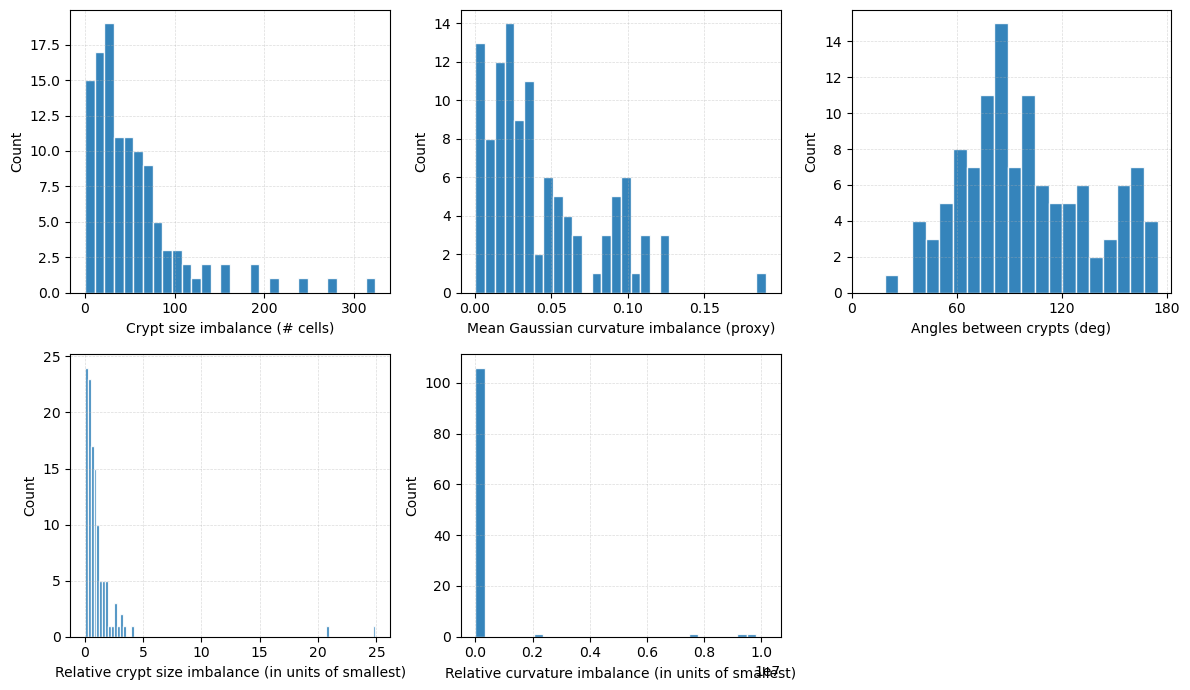

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def hks_to_curv_proxy_single_t(hks_col, t, d=2):
    """
    Convert a single HKS column (N,) at diffusion time t to a curvature-like target:
      Y_t = (6/t) * [ (4πt)^{d/2} * HKS_t - 1 ]  ~  Gaussian curvature
    Returns float32 (N,).
    """
    h = np.asarray(hks_col, dtype=np.float64).reshape(-1)
    t = float(t)
    Y = (6.0 / t) * ((4.0 * np.pi * t) ** (d / 2.0) * h - 1.0)
    return Y.astype(np.float32)

def as_patch_list(x):
    """Normalize to list[set[int]]: None -> [], set -> [set], list/tuple -> list of sets."""
    if x is None:
        return []
    if isinstance(x, set):
        return [x]
    if isinstance(x, (list, tuple)):
        return [set(p) for p in x if p is not None and len(p) > 0]
    return []

size_diff = []
curv_diff = []
size_diff_rel = []
curv_diff_rel = []
angles_deg = []  # pairwise angles between crypts (degrees)

for tp, d in results.items():
    crypts_all = d.get("crypts_all", [])
    villus_all = d.get("villus_all", [])
    Gs         = d.get("cell_graphs_all", [])

    if isinstance(crypts_all, np.ndarray): crypts_all = crypts_all.tolist()
    if isinstance(villus_all, np.ndarray): villus_all = villus_all.tolist()

    if not Gs:
        continue

    for i in range(len(Gs)):
        G = Gs[i]
        if G is None:
            continue

        crypt_patches  = as_patch_list(crypts_all[i] if i < len(crypts_all) else None)
        villus_patches = as_patch_list(villus_all[i] if i < len(villus_all) else None)

        if not villus_patches:
            continue  # need villus to define rays
        villus_patch = villus_patches[0]  # you filtered to exactly one villus earlier

        num_crypts = len(crypt_patches)
        if num_crypts < 2:
            continue

        n_cells = G.number_of_nodes()

        # --- per-cell HKS and centroids from graph nodes ---
        # HKS_cell: (N_cells, T)
        HKS_cell = np.vstack([np.asarray(G.nodes[n]["hks"], dtype=float) for n in range(n_cells)])

        # centroids: (N_cells, 3)
        C = np.vstack([np.asarray(G.nodes[n]["centroid"], dtype=float) for n in range(n_cells)])

        # --- size/curvature diffs ---
        crypt_sizes = np.zeros(num_crypts, dtype=float)
        crypt_mean_curv = np.zeros(num_crypts, dtype=float)

        for j, patch in enumerate(crypt_patches):
            idx = np.fromiter(patch, dtype=int)
            if idx.size == 0:
                crypt_sizes[j] = np.nan
                crypt_mean_curv[j] = np.nan
                continue

            curv_crypt = hks_to_curv_proxy_single_t(HKS_cell[idx, 0], 1.0)
            crypt_sizes[j] = float(idx.size)
            crypt_mean_curv[j] = float(np.nanmean(curv_crypt))

        # drop if any crypt invalid
        if not np.all(np.isfinite(crypt_sizes)) or not np.all(np.isfinite(crypt_mean_curv)):
            continue

        # absolute diffs (upper triangle)
        diff = crypt_sizes[:, None] - crypt_sizes[None, :]
        size_diff.append(diff[np.triu_indices(num_crypts, k=1)])

        min_size = float(np.min(crypt_sizes))
        size_diff_rel.append(diff[np.triu_indices(num_crypts, k=1)] / max(min_size, 1e-8))

        diff = crypt_mean_curv[:, None] - crypt_mean_curv[None, :]
        curv_diff.append(diff[np.triu_indices(num_crypts, k=1)])

        min_curv = float(np.min(crypt_mean_curv))
        curv_diff_rel.append(diff[np.triu_indices(num_crypts, k=1)] / max(min_curv, 1e-8))

        # --- ANGLES: villus→crypt rays using per-cell centroids ---
        v_idx = np.fromiter(villus_patch, dtype=int)
        if v_idx.size == 0:
            continue
        v_com = np.nanmean(C[v_idx, :], axis=0)

        rays = []
        for patch in crypt_patches:
            idx = np.fromiter(patch, dtype=int)
            if idx.size == 0:
                rays.append(np.array([np.nan, np.nan, np.nan]))
                continue
            c_com = np.nanmean(C[idx, :], axis=0)
            rays.append(c_com - v_com)

        rays = np.asarray(rays, dtype=float)  # (num_crypts, 3)
        norms = np.linalg.norm(rays, axis=1)
        valid = np.isfinite(norms) & (norms > 0)

        if np.count_nonzero(valid) < 2:
            continue

        Rn = np.zeros_like(rays)
        Rn[valid] = rays[valid] / norms[valid, None]

        cosM = np.clip(Rn @ Rn.T, -1.0, 1.0)
        theta = np.degrees(np.arccos(cosM))
        angles_deg.append(theta[np.triu_indices(num_crypts, k=1)])

# concatenate safely
def _cat_or_empty(lst):
    return np.concatenate(lst) if len(lst) else np.array([], dtype=float)

size_diff = np.abs(_cat_or_empty(size_diff))
curv_diff = np.abs(_cat_or_empty(curv_diff))
size_diff_rel = np.abs(_cat_or_empty(size_diff_rel))
curv_diff_rel = np.abs(_cat_or_empty(curv_diff_rel))
angles_deg = _cat_or_empty(angles_deg)

plt.figure(figsize=(12, 7))

plt.subplot(2, 3, 1)
plt.hist(size_diff, bins=30, edgecolor="white", alpha=0.9)
plt.xlabel("Crypt size imbalance (# cells)")
plt.ylabel("Count")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.45)
plt.tight_layout()

plt.subplot(2, 3, 2)
if curv_diff.size:
    lo, hi = np.percentile(curv_diff, [0, 95])
    plt.hist(curv_diff, bins=30, range=(lo, hi), edgecolor="white", alpha=0.9)
else:
    plt.hist(curv_diff, bins=30, edgecolor="white", alpha=0.9)
plt.xlabel("Mean Gaussian curvature imbalance (proxy)")
plt.ylabel("Count")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.45)
plt.tight_layout()

plt.subplot(2, 3, 3)
plt.hist(angles_deg, bins=20, edgecolor="white", alpha=0.9)
plt.xticks([0, 60, 120, 180])
plt.xlabel("Angles between crypts (deg)")
plt.ylabel("Count")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.45)
plt.tight_layout()

plt.subplot(2, 3, 4)
plt.hist(size_diff_rel, bins=100, edgecolor="white", alpha=0.9)
plt.xlabel("Relative crypt size imbalance (in units of smallest)")
plt.ylabel("Count")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.45)
plt.tight_layout()

plt.subplot(2, 3, 5)
if curv_diff_rel.size:
    lo, hi = np.percentile(curv_diff_rel, [0, 95])
    plt.hist(curv_diff_rel, bins=30, range=(lo, hi), edgecolor="white", alpha=0.9)
else:
    plt.hist(curv_diff_rel, bins=30, edgecolor="white", alpha=0.9)
plt.xlabel("Relative curvature imbalance (in units of smallest)")
plt.ylabel("Count")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.45)
plt.tight_layout()

plt.show()
